# 📊 Avon River - Data Analysis & Engineering
This notebook demonstrates end-to-end data analysis and engineering steps: data loading, cleaning, transformation, exploratory data analysis (EDA), and findings.

## 1. Introduction & Objectives

## 2. Importing Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## 3. Data Loading

In [2]:
# Read water quality data
water_quality = pd.read_csv('water_quality.csv', parse_dates=['Date'])
display(water_quality)

,Site ID,Date,Temperature (°C),pH,Dissolved Oxygen (mg/L)
0,AV-1,6/11/2023,13.5,7.88,7.9
1,AV-2,2/11/2023,16.8,7.33,8.2
2,AV-3,21/10/2023,15.1,7.60,7.5
3,AV-1,1/11/2023,14.0,7.05,9.0
4,AV-2,14/10/2023,15.3,7.64,6.9
5,AV-3,10/11/2023,17.9,7.22,8.4
6,AV-1,15/10/2023,13.9,7.11,7.8
7,AV-3,12/11/2023,18.6,7.33,6.5
8,AV-2,8/11/2023,15.7,7.65,9.1
9,AV-1,13/11/2023,16.2,7.50,8.6


In [3]:
# Read fish population data
fish_population = pd.read_csv('fish_population.csv', parse_dates=['Date'])
display(fish_population)

,Site ID,Date,Species,Count,Avg. Size (cm)
0,AV-1,6/11/2023,Brown Trout,12,18.3
1,AV-2,2/11/2023,Shortfin Eel,7,42.1
2,AV-3,21/10/2023,Inanga,25,7.4
3,AV-1,1/11/2023,Longfin Eel,6,38.9
4,AV-2,14/10/2023,Brown Trout,9,17.0
5,AV-3,10/11/2023,Inanga,22,8.1
6,AV-1,15/10/2023,Shortfin Eel,5,40.3
7,AV-3,12/11/2023,Inanga,30,6.9
8,AV-2,8/11/2023,Brown Trout,10,19.5
9,AV-1,13/11/2023,Inanga,18,8.2


In [4]:
# Merge datasets on Site ID and Date for combined analysis
data = pd.merge(water_quality, fish_population, on=['Site ID','Date'], how='inner')
display(data)

,Site ID,Date,Temperature (°C),pH,Dissolved Oxygen (mg/L),Species,Count,Avg. Size (cm)
0,AV-1,6/11/2023,13.5,7.88,7.9,Brown Trout,12,18.3
1,AV-2,2/11/2023,16.8,7.33,8.2,Shortfin Eel,7,42.1
2,AV-3,21/10/2023,15.1,7.60,7.5,Inanga,25,7.4
3,AV-1,1/11/2023,14.0,7.05,9.0,Longfin Eel,6,38.9
4,AV-2,14/10/2023,15.3,7.64,6.9,Brown Trout,9,17.0
5,AV-3,10/11/2023,17.9,7.22,8.4,Inanga,22,8.1
6,AV-1,15/10/2023,13.9,7.11,7.8,Shortfin Eel,5,40.3
7,AV-3,12/11/2023,18.6,7.33,6.5,Inanga,30,6.9
8,AV-2,8/11/2023,15.7,7.65,9.1,Brown Trout,10,19.5
9,AV-1,13/11/2023,16.2,7.50,8.6,Inanga,18,8.2


## 6. Exploratory Data Analysis (EDA)

### 6.1 Univariate Analysis

### 6.2 Bivariate Analysis

### 6.3 Correlation Analysis

## 7. Feature Engineering (if applicable)

## 8. Insights & Key Findings

## 9. Conclusion

## 4. Data Exploration

In [5]:
# 3.1 Summary statistics
print(data[['Temperature (°C)','pH','Dissolved Oxygen (mg/L)',
            'Count','Avg. Size (cm)']].describe())

       Temperature (°C)         pH  Dissolved Oxygen (mg/L)      Count  \
count         50.000000  50.000000                50.000000  50.000000   
mean          15.658000   7.429400                 7.944000  13.280000   
std            1.606884   0.199974                 0.692573   8.186699   
min           13.200000   7.050000                 6.500000   3.000000   
25%           14.350000   7.295000                 7.525000   6.000000   
50%           15.450000   7.415000                 7.900000  10.000000   
75%           16.575000   7.597500                 8.400000  20.750000   
max           19.700000   7.880000                 9.200000  30.000000   

       Avg. Size (cm)  
count        50.00000  
mean         22.95200  
std          15.07481  
min           6.90000  
25%           7.92500  
50%          18.15000  
75%          40.25000  
max          44.00000  


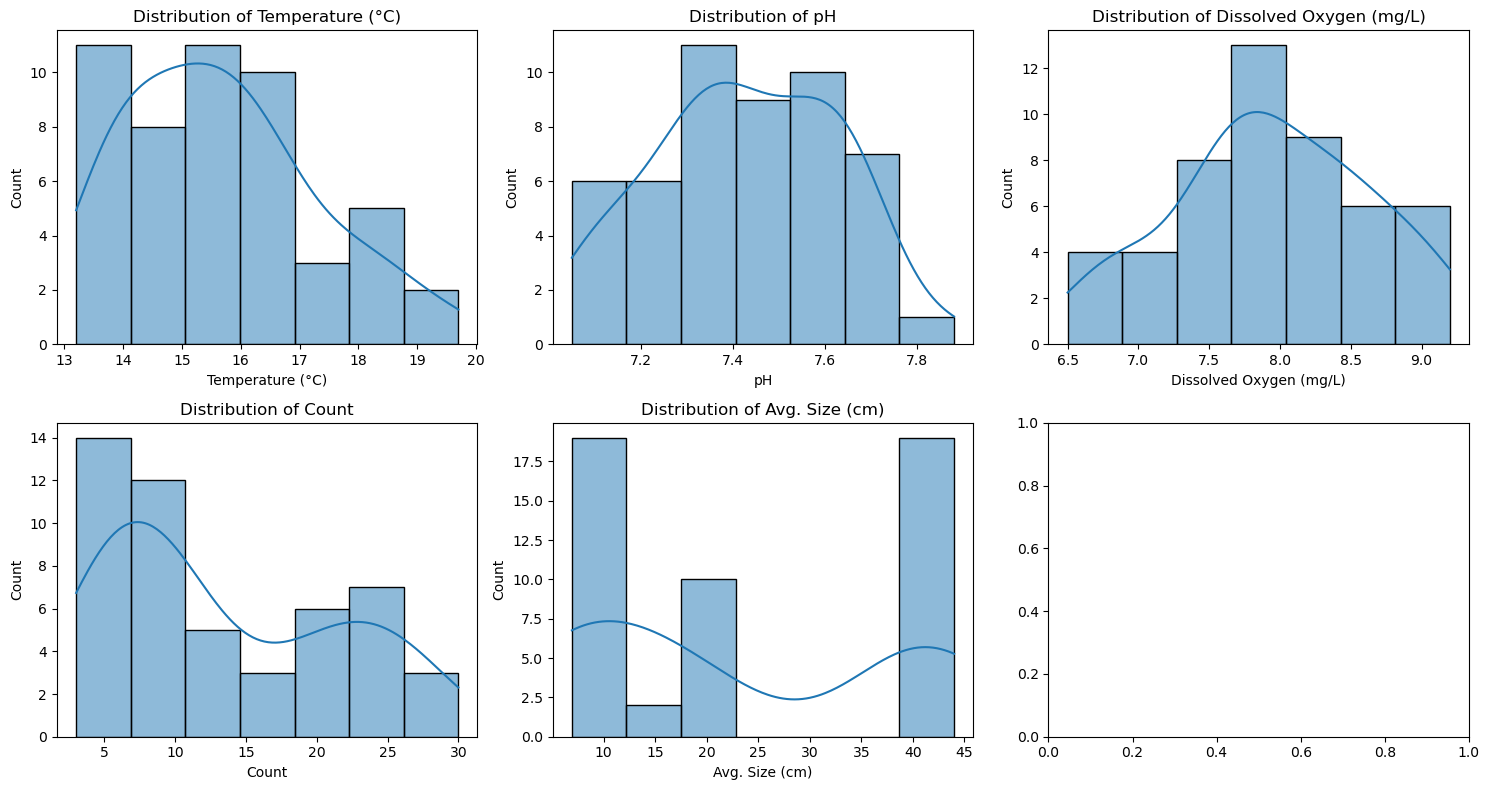

In [6]:
# 3.2 Histograms for distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), 
                   ['Temperature (°C)','pH','Dissolved Oxygen (mg/L)','Count','Avg. Size (cm)']):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## 5. Data Cleaning & Transformation

In [7]:
# Sort the data by Site ID, Date, and Species
data_sorted = data.sort_values(by=['Site ID', 'Date', 'Species'])

# Reset index after sorting for cleaner output
data_sorted = data_sorted.reset_index(drop=True)

display(data_sorted)

,Site ID,Date,Temperature (°C),pH,Dissolved Oxygen (mg/L),Species,Count,Avg. Size (cm)
0,AV-1,1/11/2023,14.0,7.05,9.0,Longfin Eel,6,38.9
1,AV-1,10/11/2023,14.8,7.36,7.6,Inanga,27,7.8
2,AV-1,11/10/2023,13.7,7.10,7.7,Inanga,20,7.5
3,AV-1,12/10/2023,13.6,7.26,7.6,Shortfin Eel,7,39.5
4,AV-1,13/11/2023,16.2,7.50,8.6,Inanga,18,8.2
5,AV-1,15/10/2023,13.9,7.11,7.8,Shortfin Eel,5,40.3
6,AV-1,20/10/2023,14.5,7.18,7.9,Longfin Eel,4,42.5
7,AV-1,22/10/2023,13.4,7.08,7.2,Shortfin Eel,4,40.0
8,AV-1,24/10/2023,14.0,7.09,6.8,Longfin Eel,5,43.0
9,AV-1,27/10/2023,14.3,7.15,6.9,Longfin Eel,6,40.7


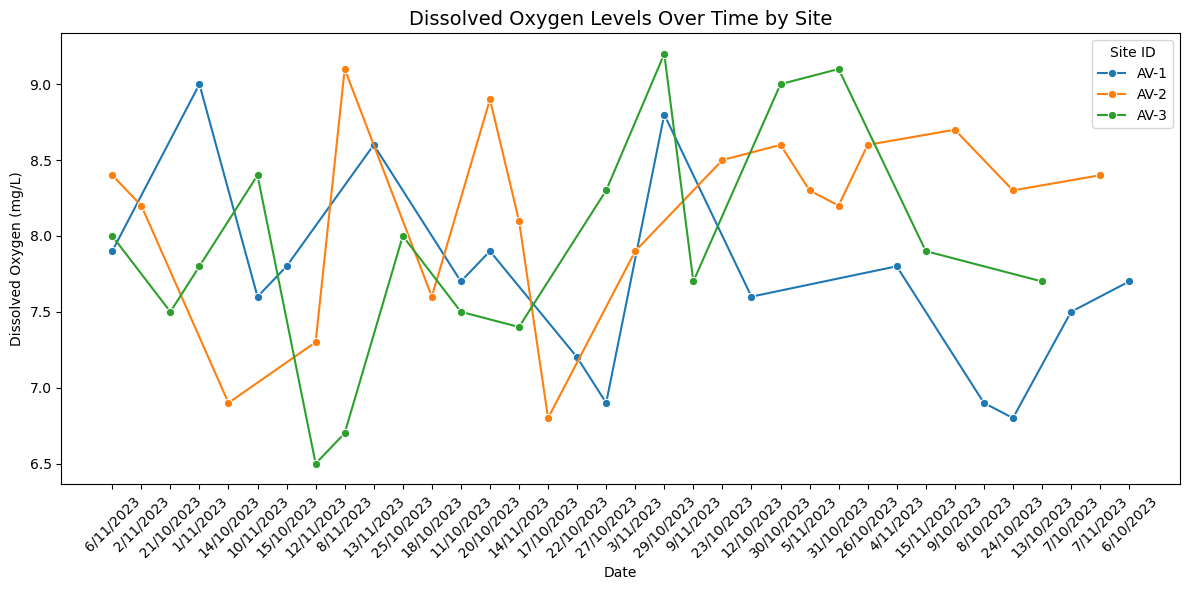

In [8]:
# Time Series Line Chart: Dissolved Oxygen for Each Site
plt.figure(figsize=(12,6))
sns.lineplot(data=water_quality, x='Date', y='Dissolved Oxygen (mg/L)', hue='Site ID', marker='o')

plt.title('Dissolved Oxygen Levels Over Time by Site', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Dissolved Oxygen (mg/L)')
plt.legend(title='Site ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


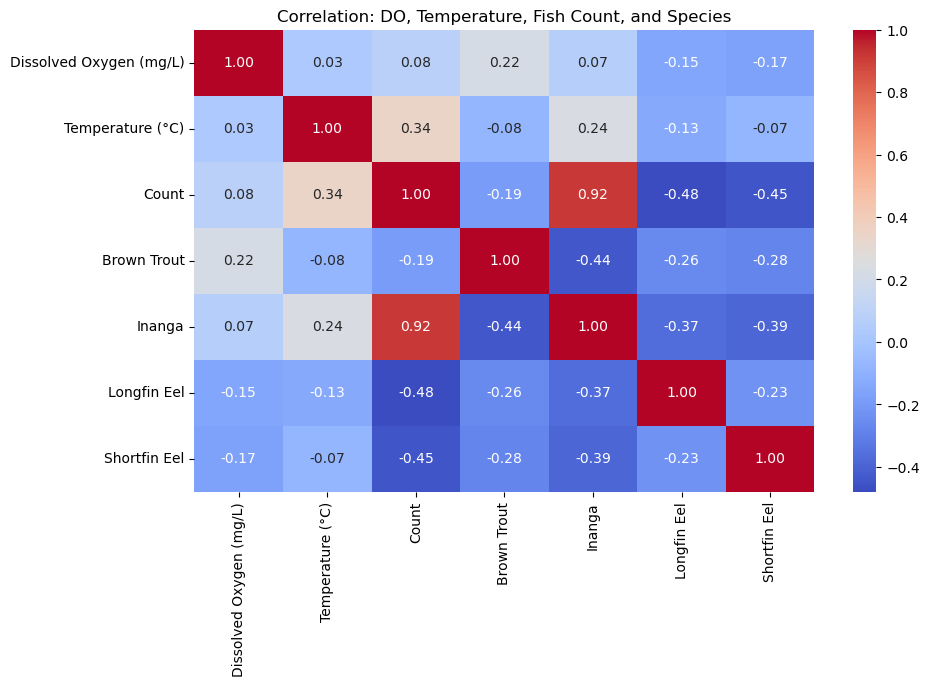

In [9]:
# One-hot encode Species
encoded = pd.get_dummies(data['Species'])

# Merge encoded species with numeric vars
species_corr_data = pd.concat([data[['Dissolved Oxygen (mg/L)', 'Temperature (°C)', 'Count']], encoded], axis=1)

# Compute correlation matrix
corr_matrix_species = species_corr_data.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix_species, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: DO, Temperature, Fish Count, and Species")
plt.show()


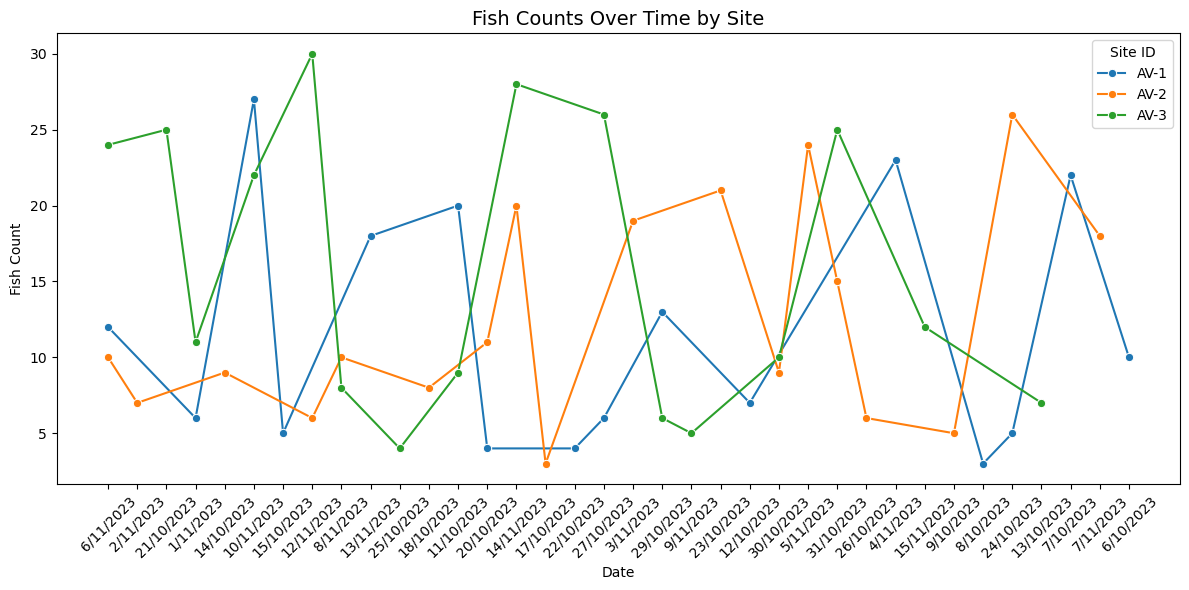

In [10]:
# Time Series Line Chart: Fish Count for Each Site
plt.figure(figsize=(12,6))
sns.lineplot(data=fish_population, x='Date', y='Count', hue='Site ID', marker='o')

plt.title('Fish Counts Over Time by Site', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Fish Count')
plt.legend(title='Site ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


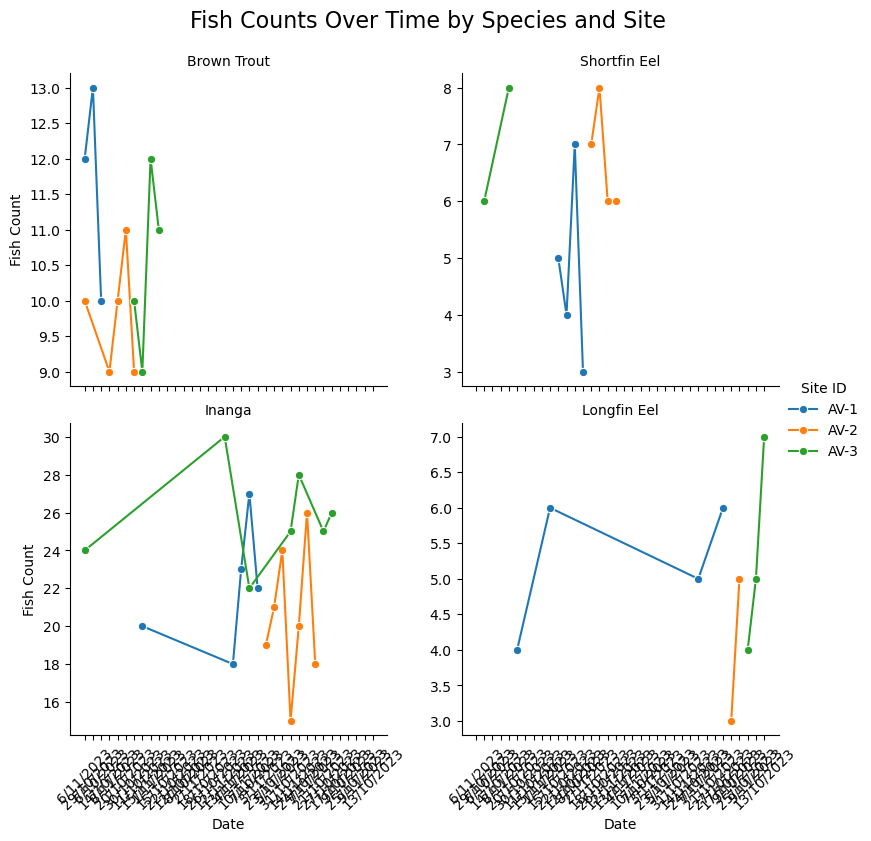

In [11]:
# Time Series Line Chart: Fish Count by Species and Site
g = sns.FacetGrid(fish_population, col="Species", hue="Site ID", col_wrap=2, height=4, sharey=False)

# Add line plots for each facet
g.map(sns.lineplot, "Date", "Count", marker="o")

# Add titles and legends
g.add_legend(title="Site ID")
g.set_axis_labels("Date", "Fish Count")
g.set_titles("{col_name}")

# Rotate x-axis labels
for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Fish Counts Over Time by Species and Site", fontsize=16)
plt.show()


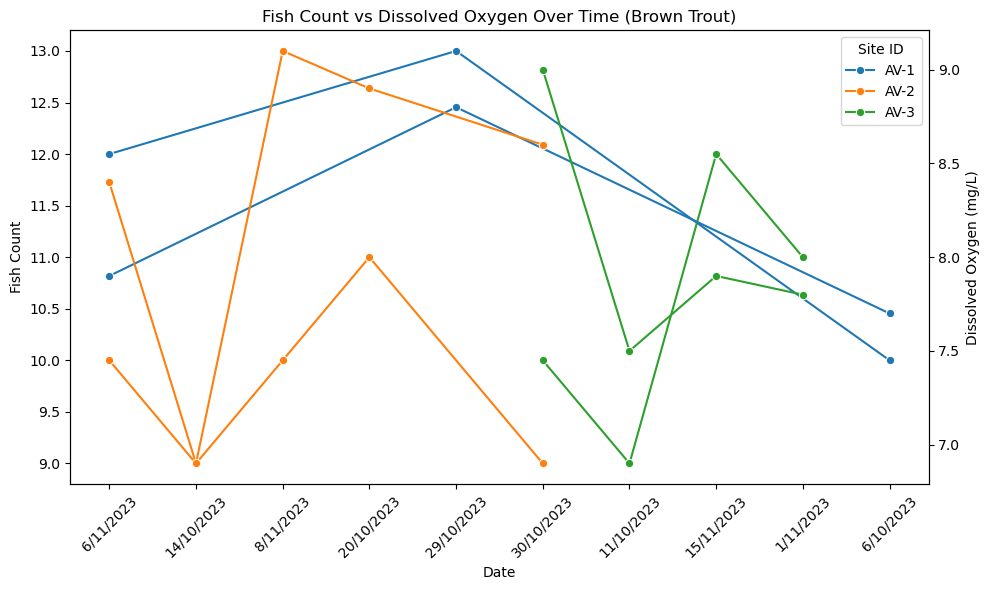

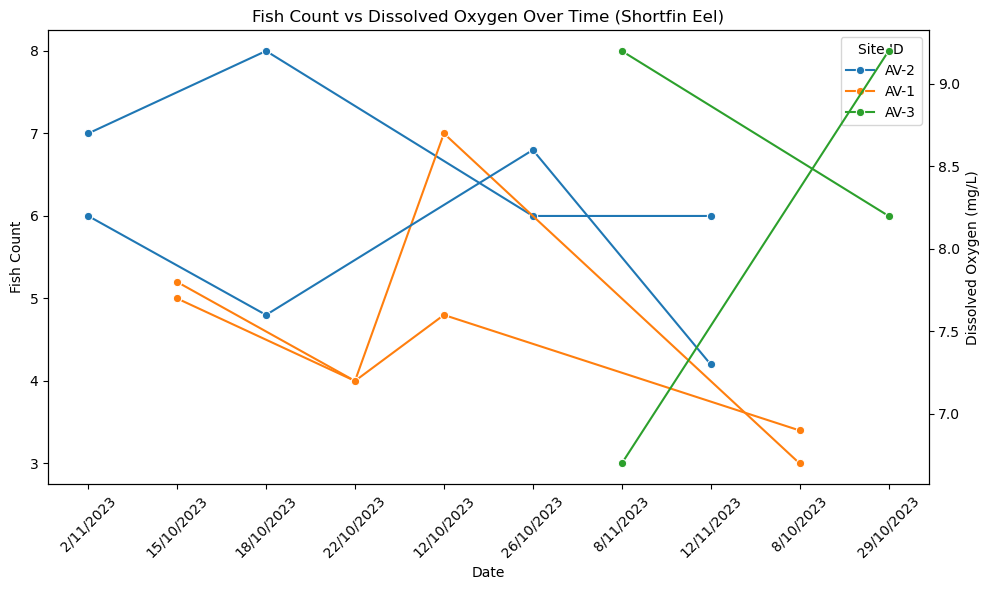

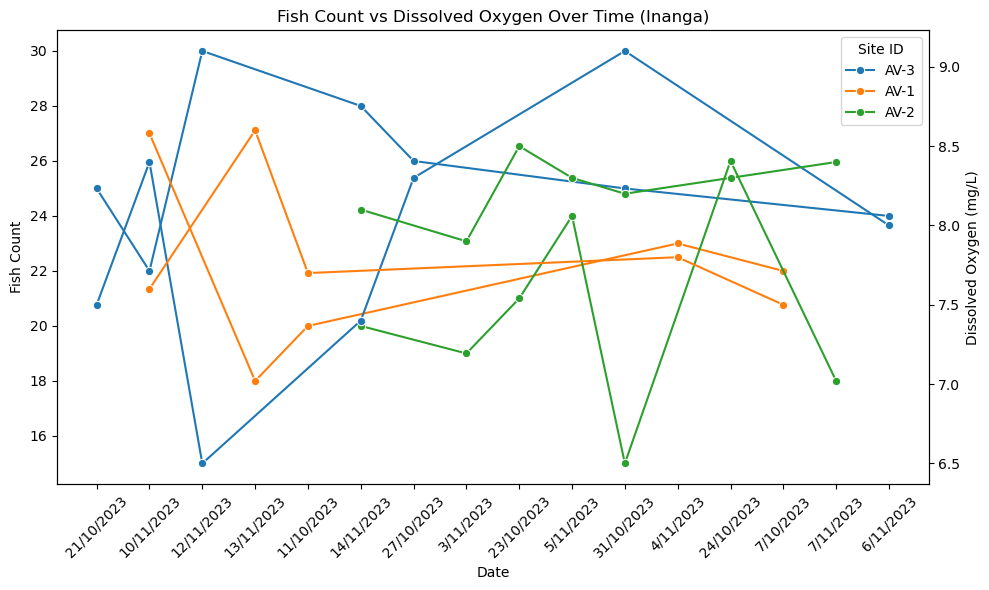

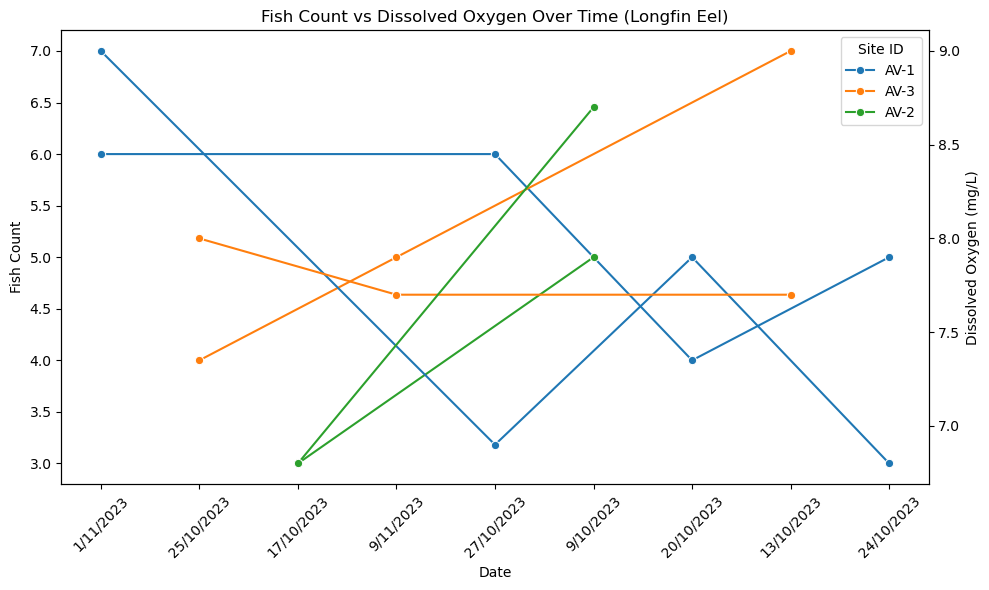

In [12]:
# Overlay DO with Fish Counts for all species
species_list = data["Species"].unique()

for species in species_list:
    plt.figure(figsize=(10, 6))
    subset = data[data["Species"] == species]

    # Left axis: Fish count
    ax1 = sns.lineplot(data=subset, x="Date", y="Count", hue="Site ID", marker="o")
    ax1.set_ylabel("Fish Count")
    ax1.set_xlabel("Date")
    ax1.tick_params(axis='x', rotation=45)

    # Right axis: Dissolved Oxygen (DO)
    ax2 = ax1.twinx()
    sns.lineplot(data=subset, x="Date", y="Dissolved Oxygen (mg/L)", hue="Site ID", 
                 style=True, markers=True, dashes=False, ax=ax2, legend=False)
    ax2.set_ylabel("Dissolved Oxygen (mg/L)")

    # Title
    plt.title(f"Fish Count vs Dissolved Oxygen Over Time ({species})")
    plt.tight_layout()
    plt.show()

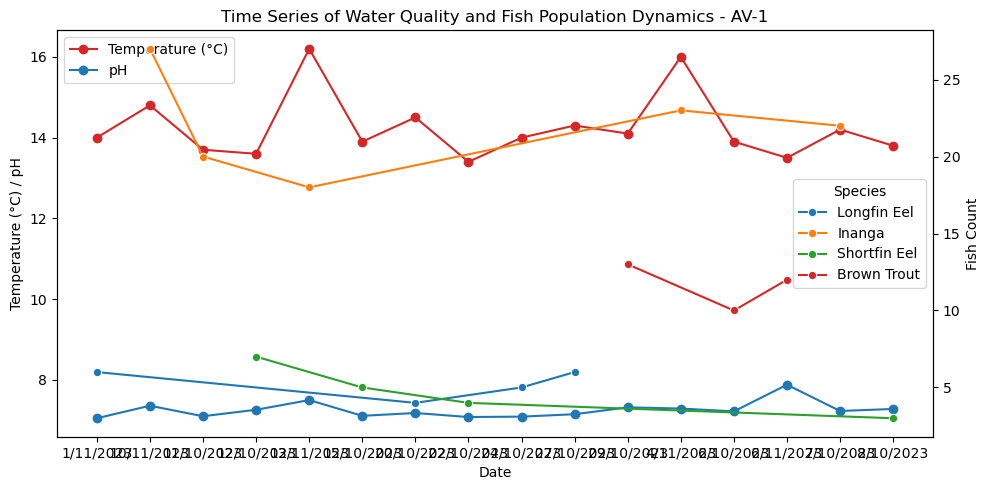

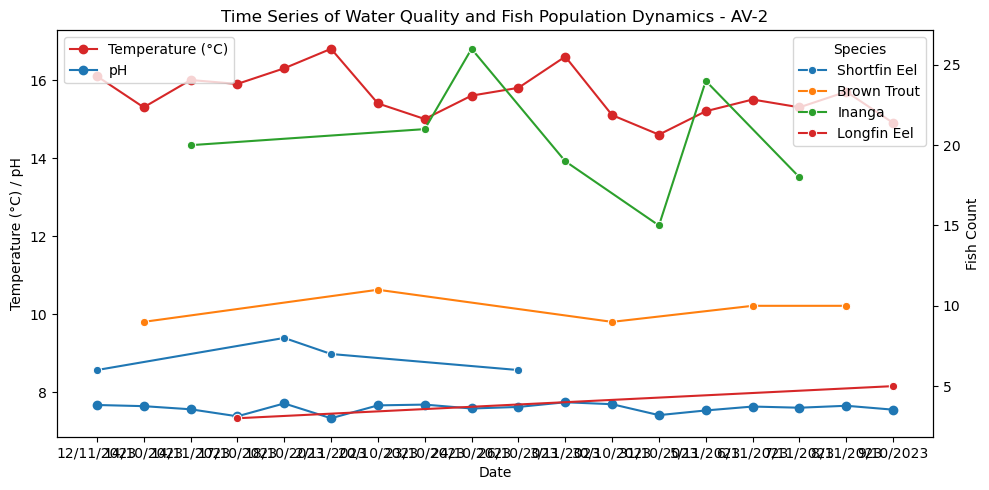

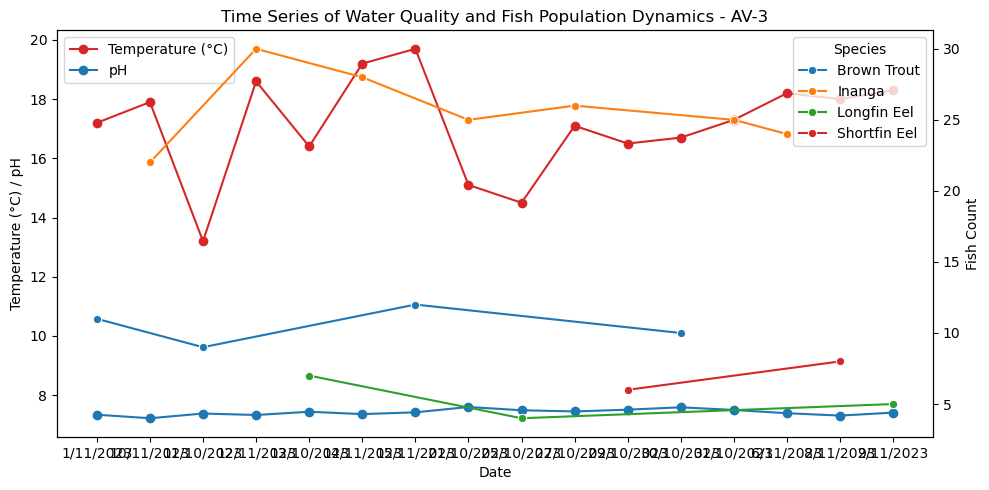

In [13]:
# Get unique sites
sites = data['Site ID'].unique()

# Loop through sites and plot
for site in sites:
    site_data = data[data['Site ID'] == site].sort_values('Date')
    
    fig, ax1 = plt.subplots(figsize=(10,5))
    
    # Plot Temperature and pH on left y-axis
    ax1.plot(site_data['Date'], site_data['Temperature (°C)'], marker='o', color='tab:red', label='Temperature (°C)')
    ax1.plot(site_data['Date'], site_data['pH'], marker='o', color='tab:blue', label='pH')
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Temperature (°C) / pH")
    ax1.legend(loc="upper left")
    
    # Fish Count on right y-axis
    ax2 = ax1.twinx()
    sns.lineplot(data=site_data, x='Date', y='Count', hue='Species', marker='o', ax=ax2)
    ax2.set_ylabel("Fish Count")
    
    plt.title(f"Time Series of Water Quality and Fish Population Dynamics - {site}")
    fig.tight_layout()
    plt.show()

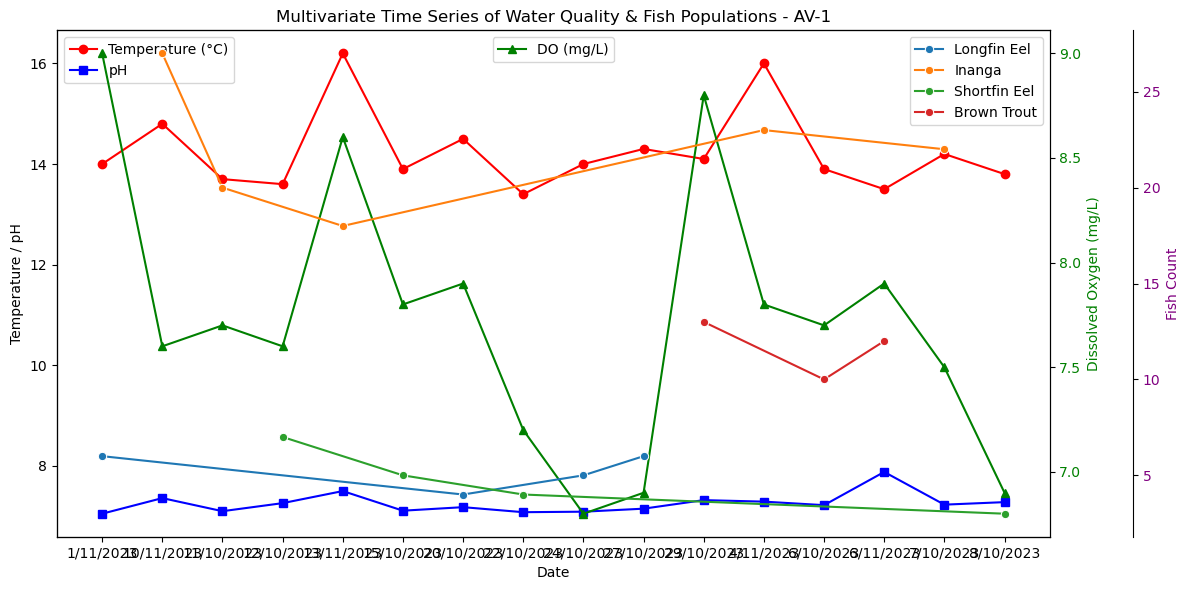

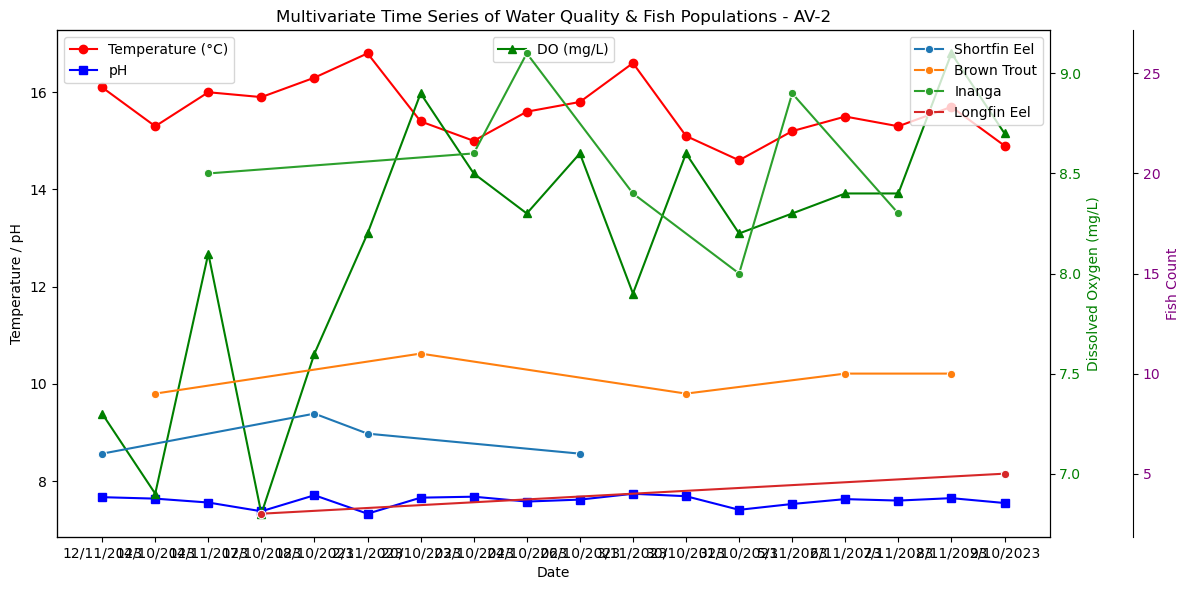

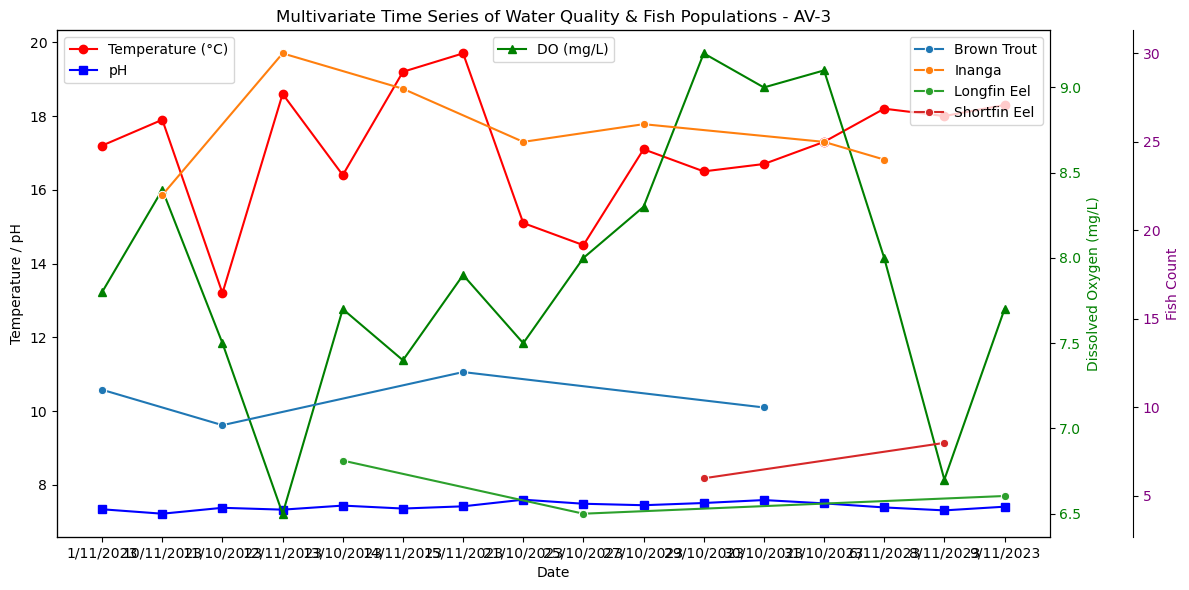

In [14]:
sites = data['Site ID'].unique()

for site in sites:
    site_data = data[data['Site ID'] == site].sort_values('Date')

    fig, ax1 = plt.subplots(figsize=(12,6))

    # Temperature & pH
    ax1.plot(site_data['Date'], site_data['Temperature (°C)'], marker='o', color='red', label='Temperature (°C)')
    ax1.plot(site_data['Date'], site_data['pH'], marker='s', color='blue', label='pH')
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Temperature / pH", color="black")
    ax1.tick_params(axis='y', labelcolor="black")
    
    # Dissolved Oxygen
    ax2 = ax1.twinx()
    ax2.plot(site_data['Date'], site_data['Dissolved Oxygen (mg/L)'], marker='^', color='green', label='DO (mg/L)')
    ax2.set_ylabel("Dissolved Oxygen (mg/L)", color="green")
    ax2.tick_params(axis='y', labelcolor="green")

    # Fish Count (species separated)
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))  # Offset third axis
    sns.lineplot(data=site_data, x='Date', y='Count', hue='Species', marker='o', ax=ax3, legend=True)
    ax3.set_ylabel("Fish Count", color="purple")
    ax3.tick_params(axis='y', labelcolor="purple")

    # Title and legends
    plt.title(f"Multivariate Time Series of Water Quality & Fish Populations - {site}")
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper center")
    ax3.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


In [15]:
import scipy.stats as stats

# Correlation test (Pearson)
corr, pval = stats.pearsonr(data['Temperature (°C)'], data['Dissolved Oxygen (mg/L)'])

print("Correlation coefficient (Temp vs DO):", corr)
print("P-value:", pval)

if pval < 0.05:
    print("Reject H₀: Significant negative relationship between Temperature and DO.")
else:
    print("Fail to reject H₀: No significant relationship.")


Correlation coefficient (Temp vs DO): 0.029384936545298772
P-value: 0.8394702617597523
Fail to reject H₀: No significant relationship.


In [16]:
# Define dependent and independent variables
X = data[['Temperature (°C)']]
y = data['Count']

# Add constant (for intercept)
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()

# Print summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Count   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     6.446
Date:                Sun, 21 Sep 2025   Prob (F-statistic):             0.0144
Time:                        19:32:13   Log-Likelihood:                -172.42
No. Observations:                  50   AIC:                             348.8
Df Residuals:                      48   BIC:                             352.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -14.1679     10.867  

In [17]:
# Are fish counts significantly different between Site AV-1 and Site AV-3

from scipy.stats import ttest_ind

# Subset fish counts for two sites
counts_av1 = data[data['Site ID'] == 'AV-1']['Count']
counts_av3 = data[data['Site ID'] == 'AV-3']['Count']

t_stat, p_val = ttest_ind(counts_av1, counts_av3)

print("t-statistic:", t_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("Reject H₀: Significant difference in fish counts between AV-1 and AV-3.")
else:
    print("Fail to reject H₀: No significant difference.")


t-statistic: -1.355949370297163
p-value: 0.18523471432301536
Fail to reject H₀: No significant difference.


In [18]:
# Are fish counts significantly different between Site AV-1 and Site AV-2
from scipy.stats import ttest_ind

# Subset fish counts for two sites
counts_av1 = data[data['Site ID'] == 'AV-1']['Count']
counts_av3 = data[data['Site ID'] == 'AV-2']['Count']

t_stat, p_val = ttest_ind(counts_av1, counts_av3)

print("t-statistic:", t_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("Reject H₀: Significant difference in fish counts between AV-1 and AV-2.")
else:
    print("Fail to reject H₀: No significant difference.")

t-statistic: -0.40757633010880095
p-value: 0.6862987025089902
Fail to reject H₀: No significant difference.


In [19]:
# Are fish counts significantly different between Site AV-2 and Site AV-3
from scipy.stats import ttest_ind

# Subset fish counts for two sites
counts_av1 = data[data['Site ID'] == 'AV-2']['Count']
counts_av3 = data[data['Site ID'] == 'AV-3']['Count']

t_stat, p_val = ttest_ind(counts_av1, counts_av3)

print("t-statistic:", t_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("Reject H₀: Significant difference in fish counts between AV-2 and AV-3.")
else:
    print("Fail to reject H₀: No significant difference.")

t-statistic: -1.1070096891060455
p-value: 0.2765421644078908
Fail to reject H₀: No significant difference.


In [20]:
high_temp_DO = data[data['Temperature (°C)'] > 18]['Dissolved Oxygen (mg/L)']
low_temp_DO = data[data['Temperature (°C)'] <= 18]['Dissolved Oxygen (mg/L)']

t_stat, p_val = ttest_ind(high_temp_DO, low_temp_DO)

print("t-statistic:", t_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("Reject H₀: DO levels differ significantly between high and low temperature groups.")
else:
    print("Fail to reject H₀: No significant difference in DO between groups.")


t-statistic: -1.531672053289799
p-value: 0.13216819250385806
Fail to reject H₀: No significant difference in DO between groups.


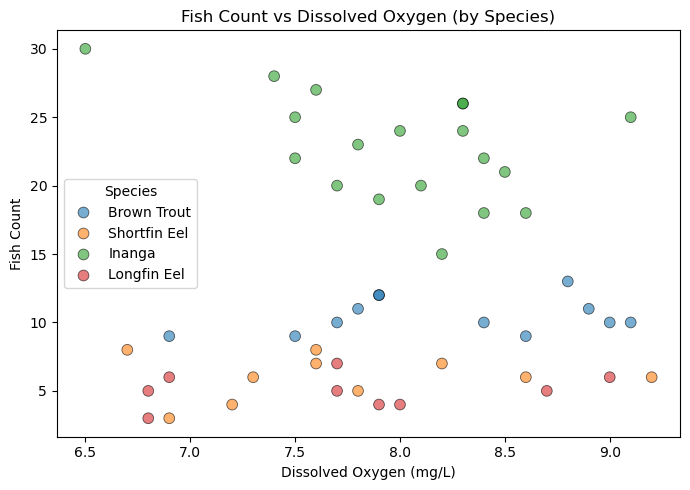

In [21]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=data,
    x='Dissolved Oxygen (mg/L)',
    y='Count',
    hue='Species',
    alpha=0.6,
    edgecolor='black',
    s=60
)

plt.title('Fish Count vs Dissolved Oxygen (by Species)')
plt.xlabel('Dissolved Oxygen (mg/L)')
plt.ylabel('Fish Count')
plt.legend(title='Species')

plt.tight_layout()
plt.show()


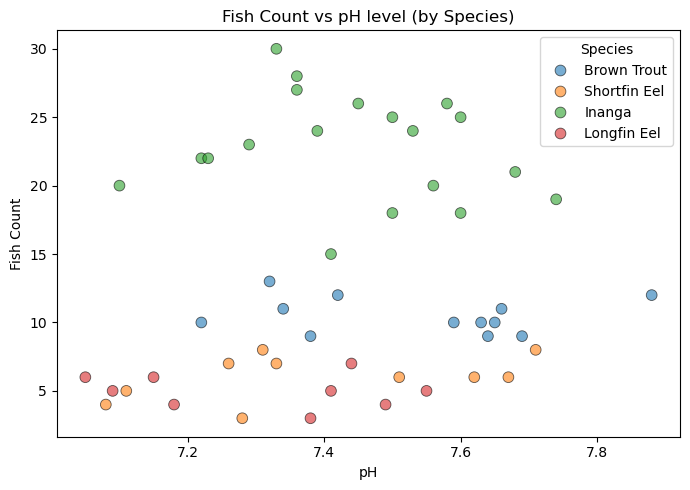

In [22]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=data,
    x='pH',
    y='Count',
    hue='Species',
    alpha=0.6,
    edgecolor='black',
    s=60
)

plt.title('Fish Count vs pH level (by Species)')
plt.xlabel('pH')
plt.ylabel('Fish Count')
plt.legend(title='Species')

plt.tight_layout()
plt.show()


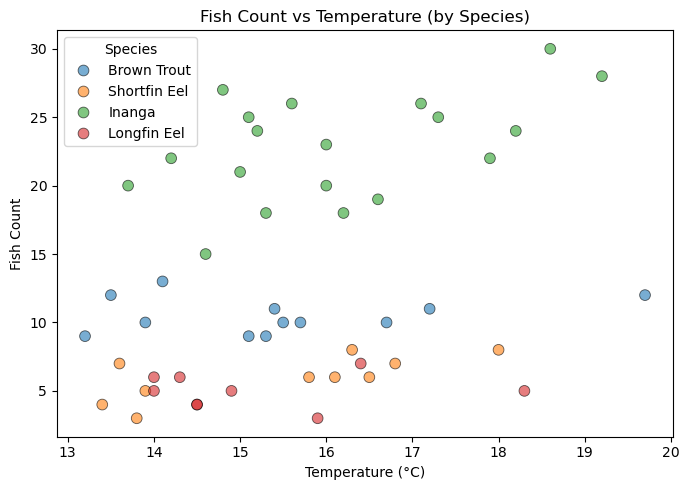

In [23]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=data,
    x='Temperature (°C)',
    y='Count',
    hue='Species',
    alpha=0.6,
    edgecolor='black',
    s=60
)

plt.title('Fish Count vs Temperature (by Species)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Fish Count')
plt.legend(title='Species')

plt.tight_layout()
plt.show()


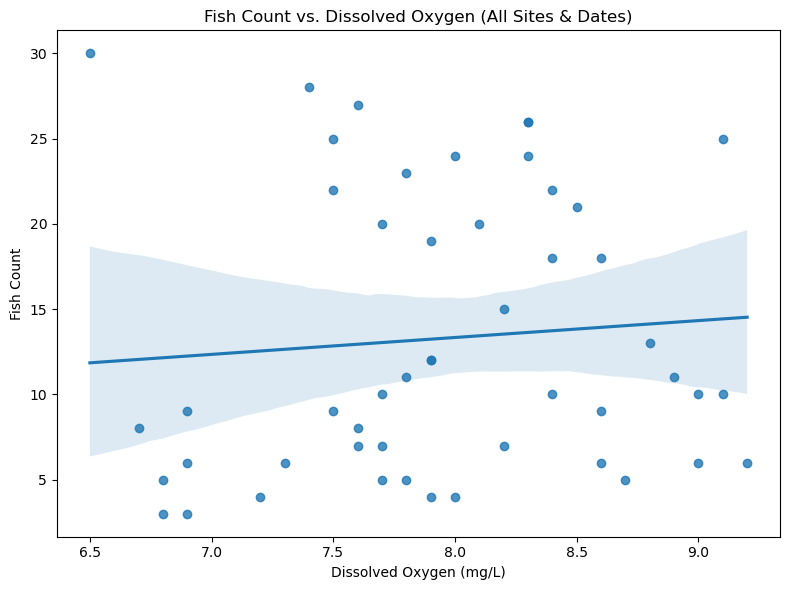

In [24]:
# 2. Scatter Plot with Trendline: Dissolved Oxygen vs. Fish Count
plt.figure(figsize=(8,6))
sns.regplot(x=data['Dissolved Oxygen (mg/L)'], y=data['Count'], scatter=True, ci=95)
plt.title('Fish Count vs. Dissolved Oxygen (All Sites & Dates)')
plt.xlabel('Dissolved Oxygen (mg/L)')
plt.ylabel('Fish Count')
plt.tight_layout()
plt.show()

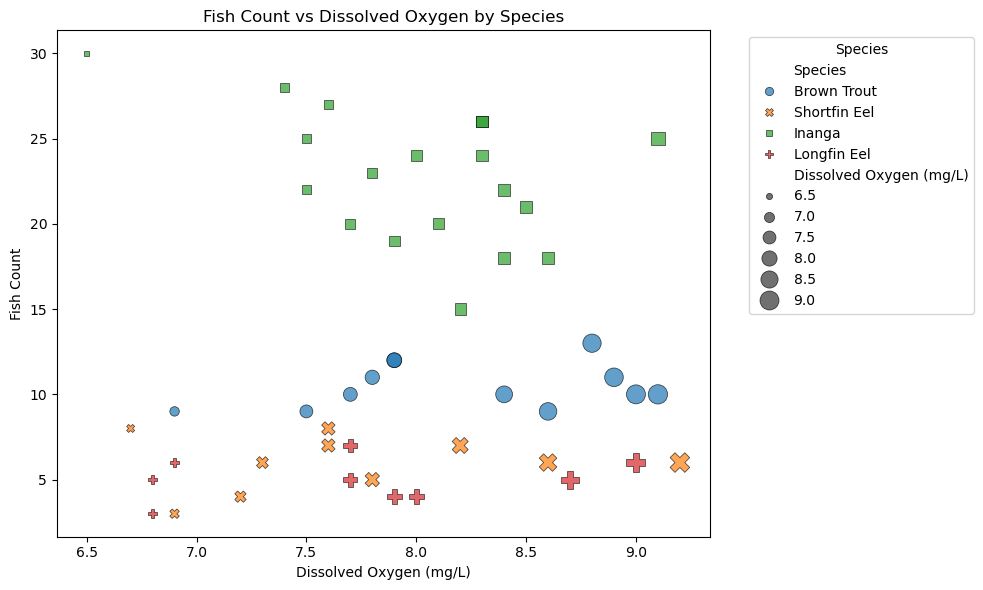

In [25]:
# Scatter plot: Fish Count vs Dissolved Oxygen, coloured by Site and shaped by Species
plt.figure(figsize=(10, 6))

# Use seaborn scatterplot with hue as Species and size representing DO levels
sns.scatterplot(
    data=data,
    x='Dissolved Oxygen (mg/L)',
    y='Count',
    hue='Species',
    palette='tab10',  # categorical palette for fish species
    style='Species',  # different markers for species
    size='Dissolved Oxygen (mg/L)',  # point size proportional to DO levels
    sizes=(20, 200),  # min and max marker sizes
    alpha=0.7,
    edgecolor='black'
)

plt.title('Fish Count vs Dissolved Oxygen by Species')
plt.xlabel('Dissolved Oxygen (mg/L)')
plt.ylabel('Fish Count')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

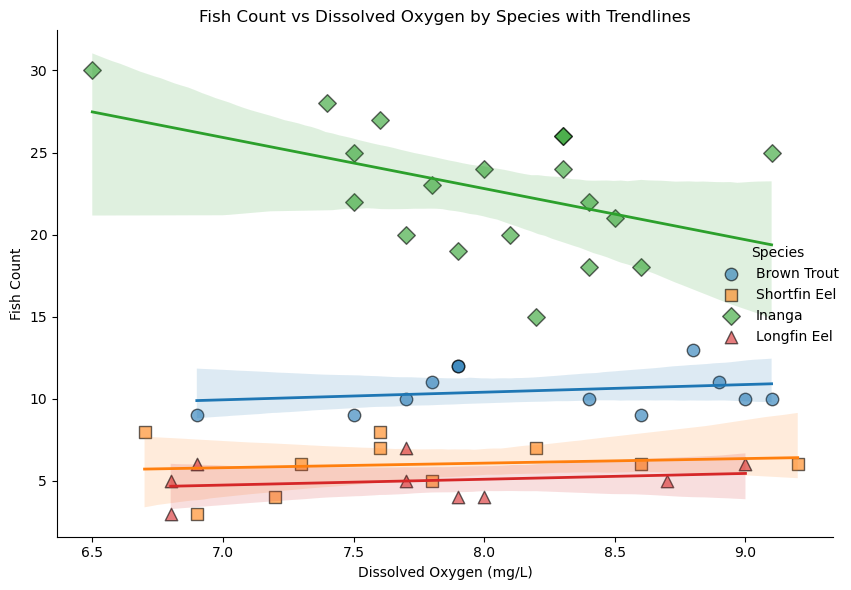

In [26]:
species_list = data['Species'].unique()
markers = ['o', 's', 'D', '^']  # one filled marker for each species

sns.lmplot(
    data=data,
    x='Dissolved Oxygen (mg/L)',
    y='Count',
    hue='Species',
    markers=markers,
    palette='tab10',
    height=6,
    aspect=1.2,
    scatter_kws={'alpha':0.6, 'edgecolor':'black', 's':80},
    line_kws={'linewidth':2}
)

plt.title('Fish Count vs Dissolved Oxygen by Species with Trendlines')
plt.xlabel('Dissolved Oxygen (mg/L)')
plt.ylabel('Fish Count')
plt.tight_layout()
plt.show()


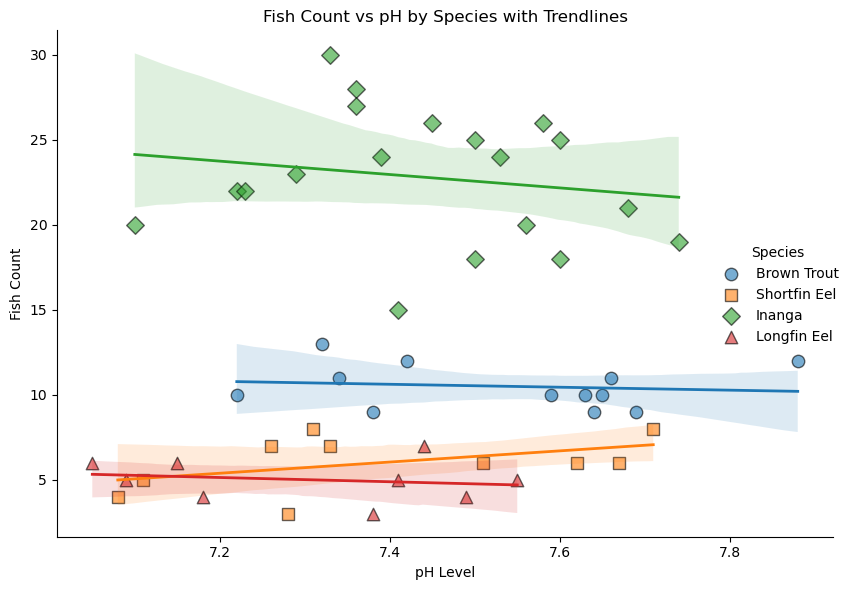

In [27]:
species_list = data['Species'].unique()
markers = ['o', 's', 'D', '^']  # one filled marker for each species

sns.lmplot(
    data=data,
    x='pH',
    y='Count',
    hue='Species',
    markers=markers,
    palette='tab10',
    height=6,
    aspect=1.2,
    scatter_kws={'alpha':0.6, 'edgecolor':'black', 's':80},
    line_kws={'linewidth':2}
)

plt.title('Fish Count vs pH by Species with Trendlines')
plt.xlabel('pH Level')
plt.ylabel('Fish Count')
plt.tight_layout()
plt.show()


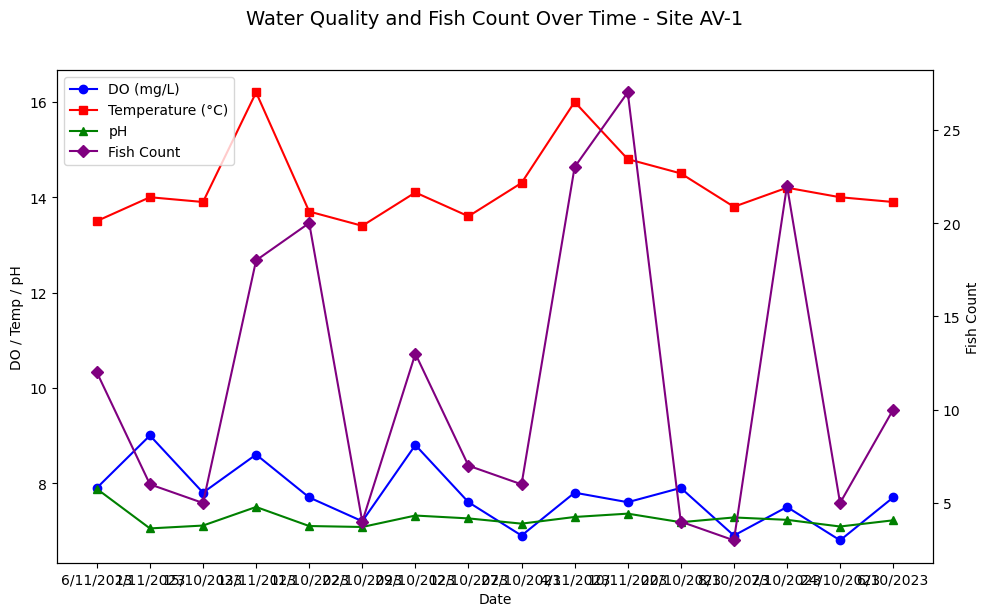

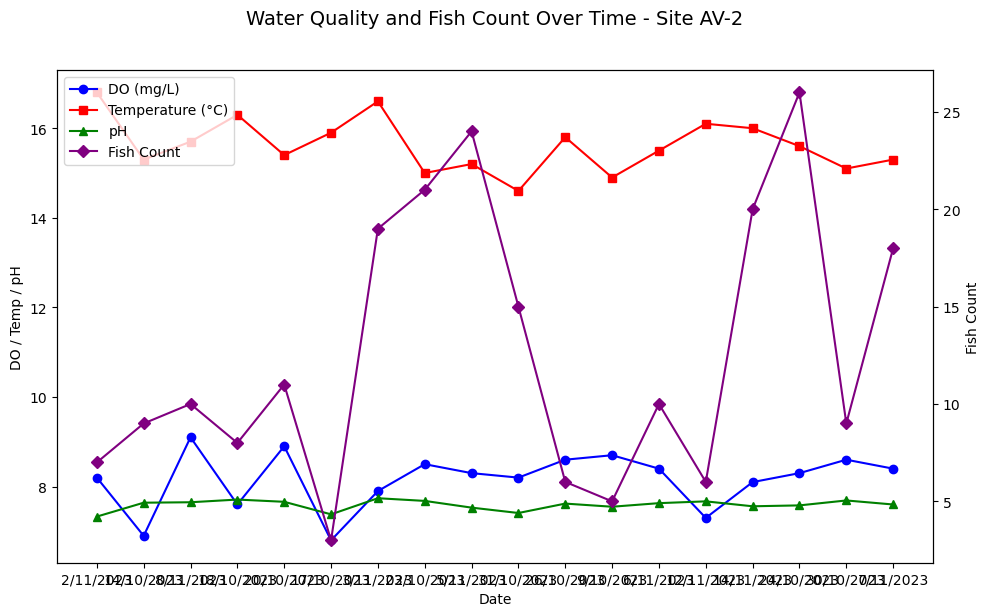

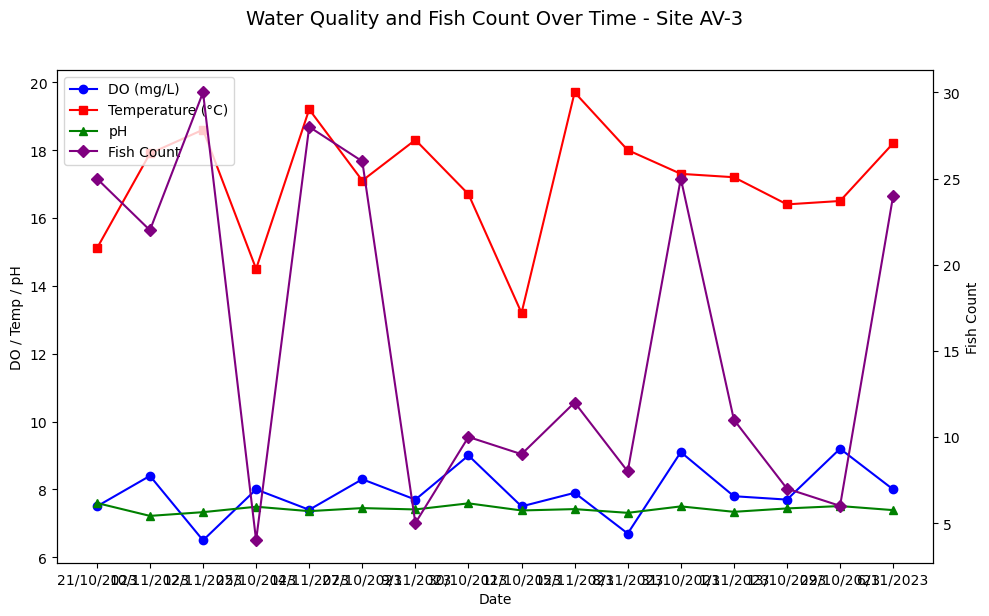

In [28]:
# Loop through each site
for site, subset in data.groupby('Site ID'):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Plot DO, Temperature, and pH with markers
    ax1.plot(subset['Date'], subset['Dissolved Oxygen (mg/L)'], marker='o', linestyle='-', color='blue', label='DO (mg/L)')
    ax1.plot(subset['Date'], subset['Temperature (°C)'], marker='s', linestyle='-', color='red', label='Temperature (°C)')
    ax1.plot(subset['Date'], subset['pH'], marker='^', linestyle='-', color='green', label='pH')
    
    ax1.set_xlabel("Date")
    ax1.set_ylabel("DO / Temp / pH")
    ax1.tick_params(axis='y')
    
    # Plot fish count on secondary axis with distinct marker
    ax2 = ax1.twinx()
    ax2.plot(subset['Date'], subset['Count'], marker='D', linestyle='-', color='purple', label='Fish Count')
    ax2.set_ylabel("Fish Count")
    ax2.tick_params(axis='y')
    
    # Title
    fig.suptitle(f"Water Quality and Fish Count Over Time - Site {site}", fontsize=14, y=1.02)
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

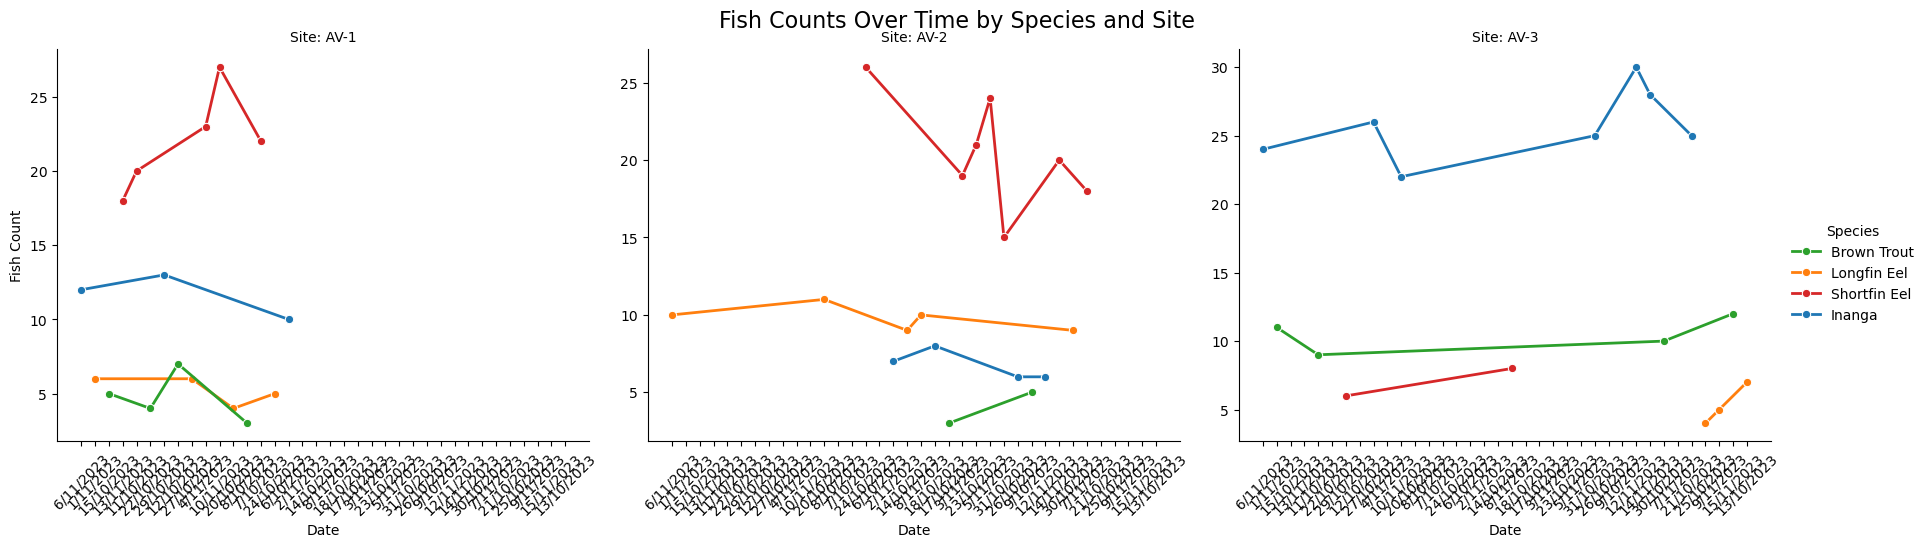

In [29]:
# Plot Fish Count over time for each species per site
g = sns.FacetGrid(data, col="Site ID", height=5, aspect=1.2, sharey=False)

# Map lineplot with markers to each facet
g.map_dataframe(
    sns.lineplot,
    x="Date",
    y="Count",
    hue="Species",
    marker="o",
    linewidth=2
)

# Add titles, axis labels, and legends
g.set_axis_labels("Date", "Fish Count")
g.set_titles("Site: {col_name}")
g.add_legend(title="Species")

# Rotate x-axis labels for readability
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Fish Counts Over Time by Species and Site", fontsize=16)
plt.show()


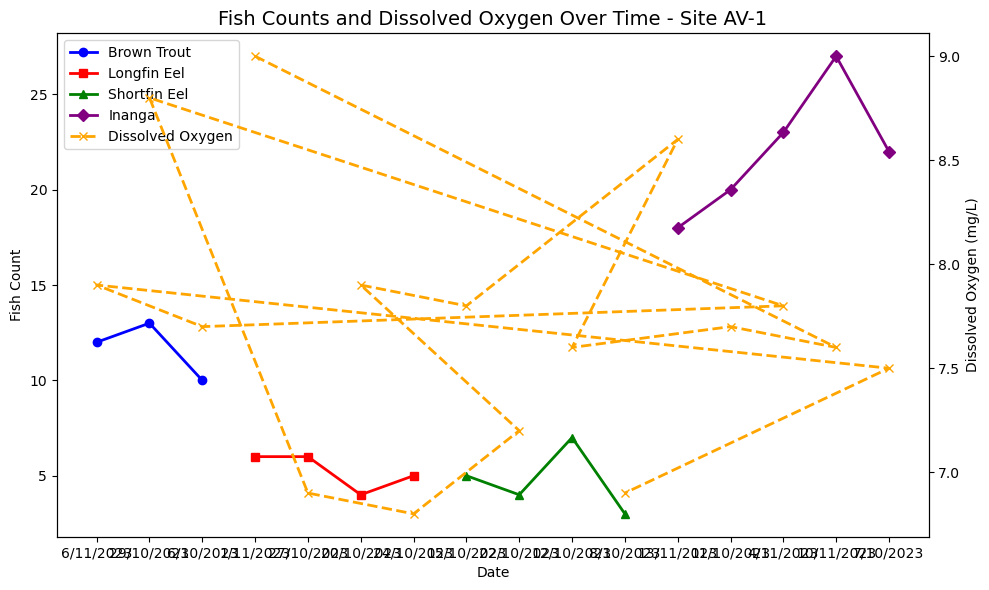

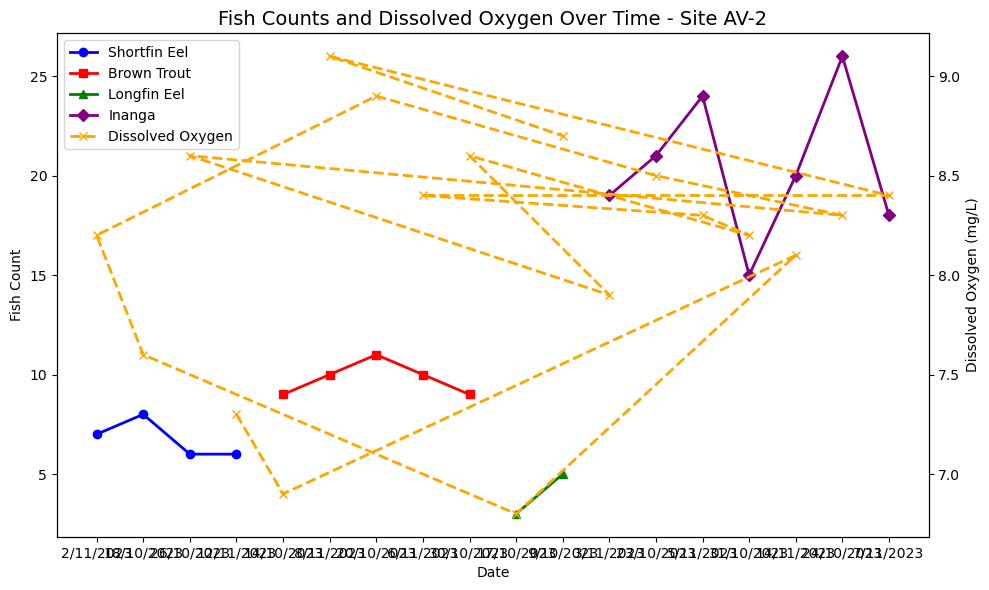

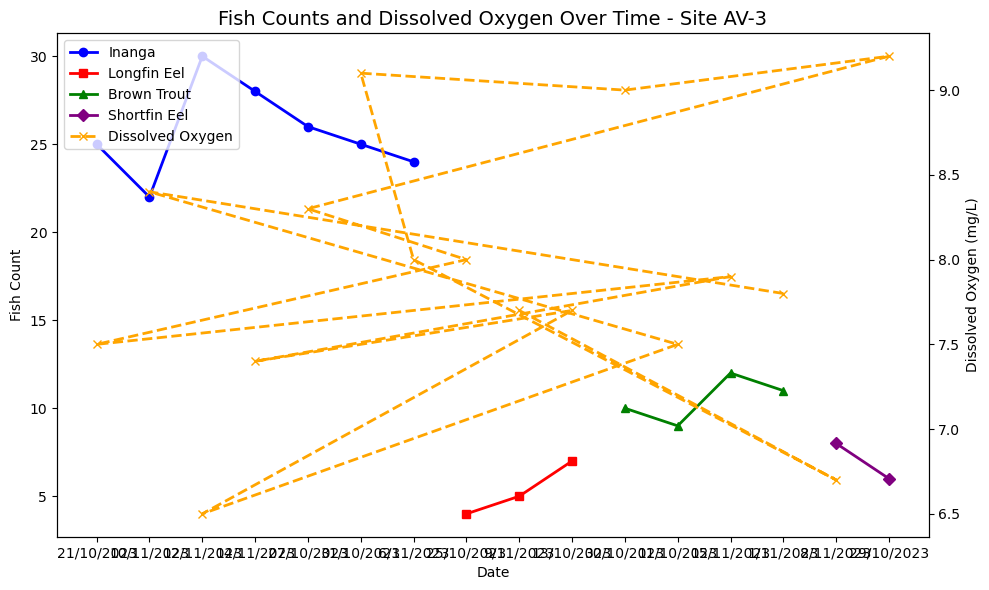

In [30]:
# Loop through each site to create a facet-style layout
for site, subset in data.groupby('Site ID'):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Plot fish count per species on primary y-axis
    species_list = subset['Species'].unique()
    markers = ['o', 's', '^', 'D']  # One marker per species
    colors = ['blue', 'red', 'green', 'purple']
    
    for i, species in enumerate(species_list):
        species_data = subset[subset['Species'] == species]
        ax1.plot(
            species_data['Date'], species_data['Count'],
            marker=markers[i % len(markers)],
            color=colors[i % len(colors)],
            linestyle='-',
            linewidth=2,
            label=species
        )
    
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Fish Count")
    ax1.tick_params(axis='y')
    
    # Plot DO on secondary y-axis
    ax2 = ax1.twinx()
    # Aggregate DO per date (mean if multiple species)
    do_data = subset.groupby('Date')['Dissolved Oxygen (mg/L)'].mean().reset_index()
    ax2.plot(
        do_data['Date'], do_data['Dissolved Oxygen (mg/L)'],
        color='orange', marker='x', linestyle='--', linewidth=2, label='Dissolved Oxygen'
    )
    ax2.set_ylabel("Dissolved Oxygen (mg/L)")
    ax2.tick_params(axis='y')
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.title(f"Fish Counts and Dissolved Oxygen Over Time - Site {site}", fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [31]:

# Group by species and calculate correlation
corr_results = (
    data.groupby("Species")
        .apply(lambda g: pd.Series({
            "Corr_DO_Count": g["Dissolved Oxygen (mg/L)"].corr(g["Count"]),
            "Corr_Temp_Count": g["Temperature (°C)"].corr(g["Count"])
        }))
        .reset_index()
)

display(corr_results)


C:\Users\desha\AppData\Local\Temp\ipykernel_51232\1222621673.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,Species,Corr_DO_Count,Corr_Temp_Count
0,Brown Trout,0.244860,0.193121
1,Inanga,-0.458185,0.500843
2,Longfin Eel,0.230643,0.021450
3,Shortfin Eel,0.131896,0.712589


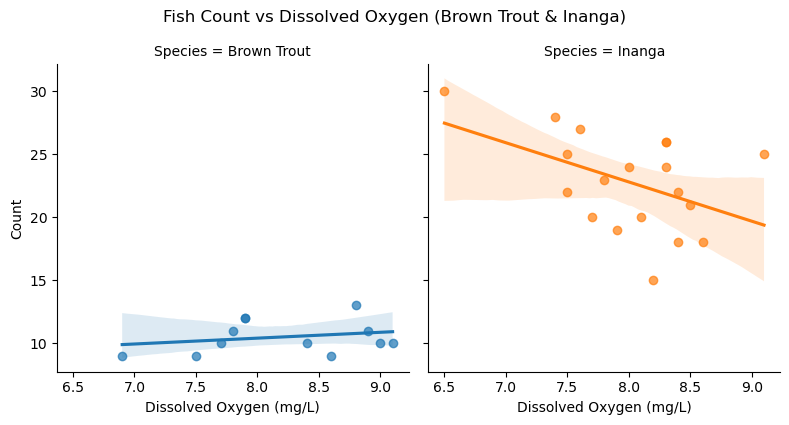

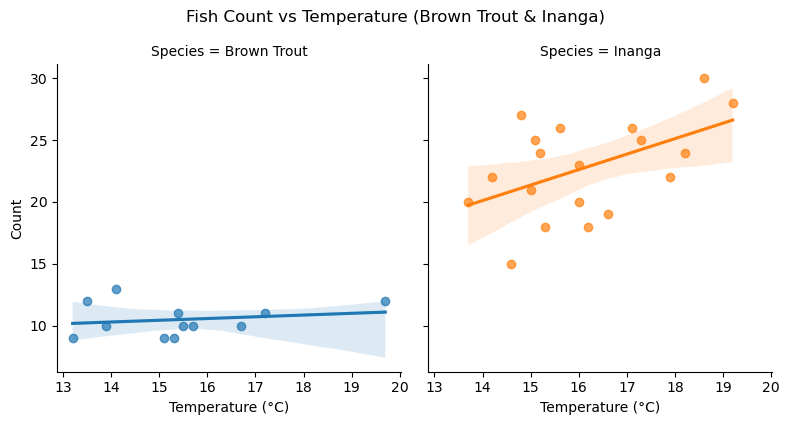

In [32]:
# Dissolved Oxygen vs Count
sns.lmplot(
    data=data[data["Species"].isin(["Brown Trout", "Inanga"])],
    x="Dissolved Oxygen (mg/L)", y="Count",
    hue="Species", col="Species", 
    height=4, aspect=1, scatter_kws={'alpha':0.7}
)
plt.suptitle("Fish Count vs Dissolved Oxygen (Brown Trout & Inanga)", y=1.05)
plt.show()

# Temperature vs Count
sns.lmplot(
    data=data[data["Species"].isin(["Brown Trout", "Inanga"])],
    x="Temperature (°C)", y="Count",
    hue="Species", col="Species", 
    height=4, aspect=1, scatter_kws={'alpha':0.7}
)
plt.suptitle("Fish Count vs Temperature (Brown Trout & Inanga)", y=1.05)
plt.show()


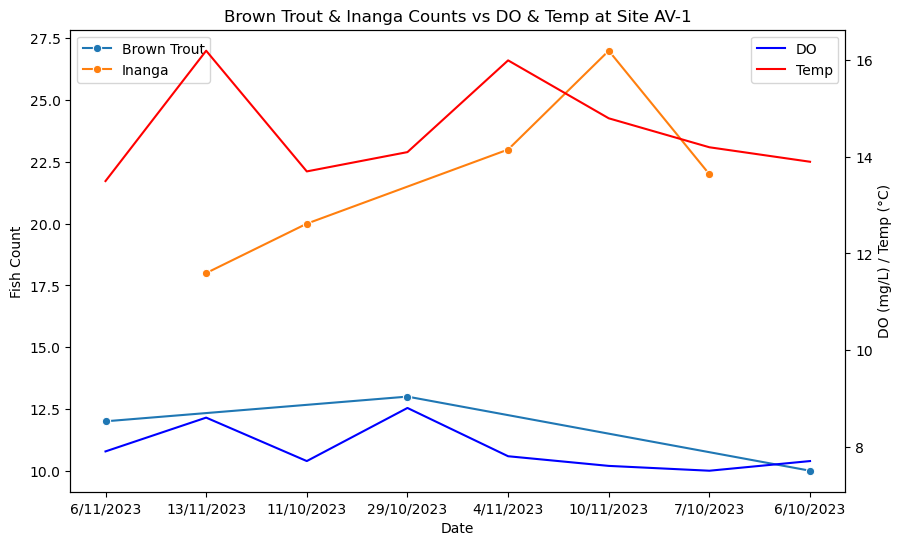

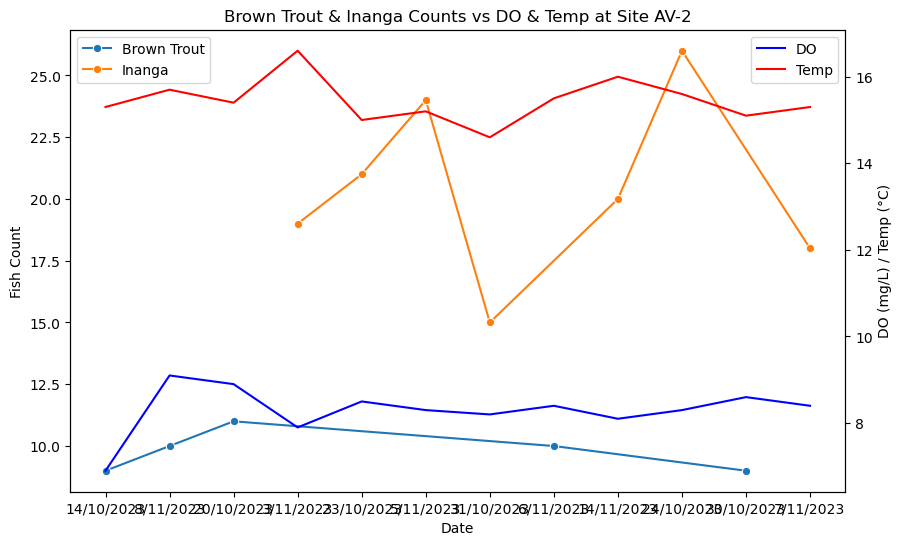

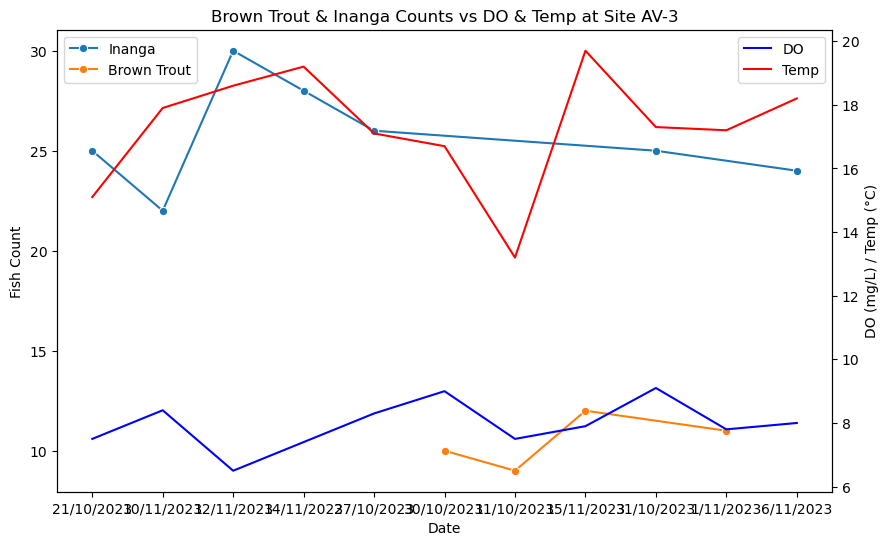

In [33]:
species_focus = ["Brown Trout", "Inanga"]

for site in data["Site ID"].unique():
    plt.figure(figsize=(10,6))
    subset = data[(data["Site ID"] == site) & (data["Species"].isin(species_focus))]
    
    # Plot DO and Temp on secondary axis
    ax = sns.lineplot(data=subset, x="Date", y="Count", hue="Species", marker="o")
    ax2 = ax.twinx()
    sns.lineplot(data=subset, x="Date", y="Dissolved Oxygen (mg/L)", color="blue", label="DO", ax=ax2)
    sns.lineplot(data=subset, x="Date", y="Temperature (°C)", color="red", label="Temp", ax=ax2)
    
    ax.set_ylabel("Fish Count")
    ax2.set_ylabel("DO (mg/L) / Temp (°C)")
    ax.set_title(f"Brown Trout & Inanga Counts vs DO & Temp at Site {site}")
    
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.show()


In [34]:
corr_results_temp_ph = (
    data.groupby("Species")
        .apply(lambda g: pd.Series({
            "Corr_Temp_Count": g["Temperature (°C)"].corr(g["Count"]),
            "Corr_pH_Count": g["pH"].corr(g["Count"])
        }))
        .reset_index()
)

display(corr_results_temp_ph)


C:\Users\desha\AppData\Local\Temp\ipykernel_51232\2266781051.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,Species,Corr_Temp_Count,Corr_pH_Count
0,Brown Trout,0.193121,-0.128096
1,Inanga,0.500843,-0.170197
2,Longfin Eel,0.021450,-0.190933
3,Shortfin Eel,0.712589,0.456693


In [35]:
# Example analysis in Jupyter Notebook

# Average values per site
site_summary = data.groupby("Site ID")[["Temperature (°C)", "pH", "Count"]].mean().reset_index()

# Compare fish counts at sites with lower vs higher pH
example_sites = site_summary[(site_summary["pH"] < 7.3) | (site_summary["pH"] > 7.4)]
print(example_sites)


  Site ID  Temperature (°C)        pH      Count
0    AV-1         14.243750  7.256250  11.562500
1    AV-2         15.616667  7.590556  12.611111
2    AV-3         17.118750  7.421250  15.750000


,Site ID,Temperature (°C),pH,Average Fish Count
0,AV-1,14.243750,7.256250,11.562500
1,AV-2,15.616667,7.590556,12.611111
2,AV-3,17.118750,7.421250,15.750000


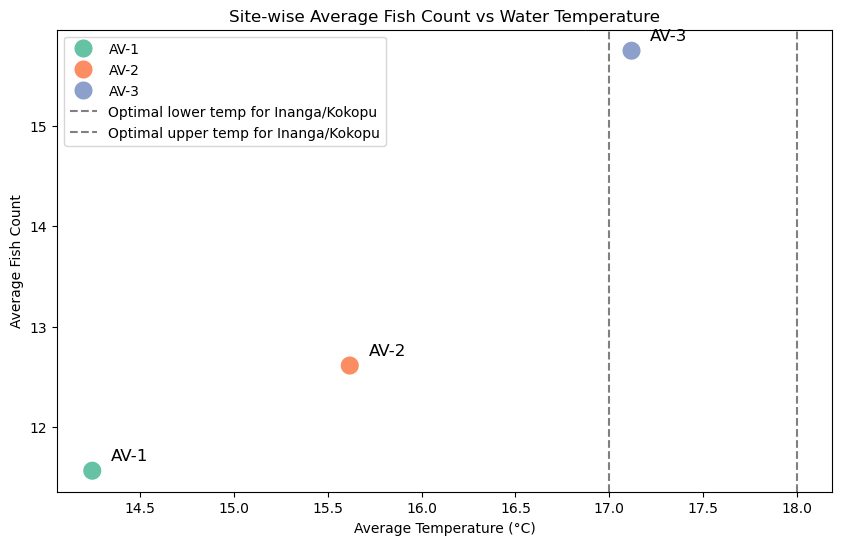

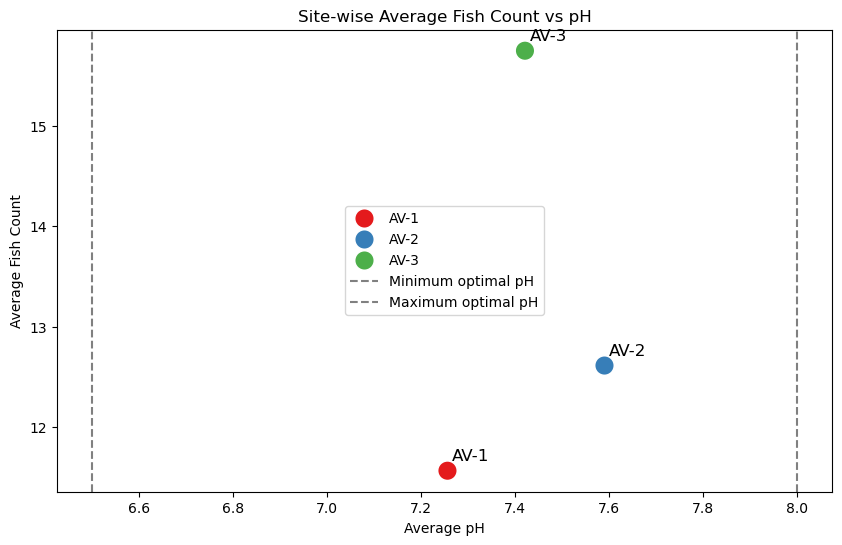

In [36]:
## Read the datasets
#water_quality = pd.read_csv('water_quality.csv', parse_dates=['Date'])
#fish_population = pd.read_csv('fish_population.csv', parse_dates=['Date'])

## Merge datasets on Site ID and Date
#data = pd.merge(water_quality, fish_population, on=['Site ID', 'Date'], how='inner')

# Calculate site-wise averages for Temperature, pH, and Fish Count
site_summary = data.groupby('Site ID').agg({
    'Temperature (°C)': 'mean',
    'pH': 'mean',
    'Count': 'mean'
}).reset_index().rename(columns={'Count': 'Average Fish Count'})

display(site_summary)

# Scatter plot: Temperature vs Fish Count per site
plt.figure(figsize=(10,6))
sns.scatterplot(data=site_summary, x='Temperature (°C)', y='Average Fish Count', hue='Site ID', s=200, palette='Set2')
for i in range(site_summary.shape[0]):
    plt.text(site_summary['Temperature (°C)'][i]+0.1, 
             site_summary['Average Fish Count'][i]+0.1, 
             site_summary['Site ID'][i], fontsize=12)
plt.axvline(x=17, color='gray', linestyle='--', label='Optimal lower temp for Inanga/Kokopu')
plt.axvline(x=18, color='gray', linestyle='--', label='Optimal upper temp for Inanga/Kokopu')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Average Fish Count')
plt.title('Site-wise Average Fish Count vs Water Temperature')
plt.legend()
plt.show()

# Scatter plot: pH vs Fish Count per site
plt.figure(figsize=(10,6))
sns.scatterplot(data=site_summary, x='pH', y='Average Fish Count', hue='Site ID', s=200, palette='Set1')
for i in range(site_summary.shape[0]):
    plt.text(site_summary['pH'][i]+0.01, 
             site_summary['Average Fish Count'][i]+0.1, 
             site_summary['Site ID'][i], fontsize=12)
plt.axvline(x=6.5, color='gray', linestyle='--', label='Minimum optimal pH')
plt.axvline(x=8.0, color='gray', linestyle='--', label='Maximum optimal pH')
plt.xlabel('Average pH')
plt.ylabel('Average Fish Count')
plt.title('Site-wise Average Fish Count vs pH')
plt.legend()
plt.show()

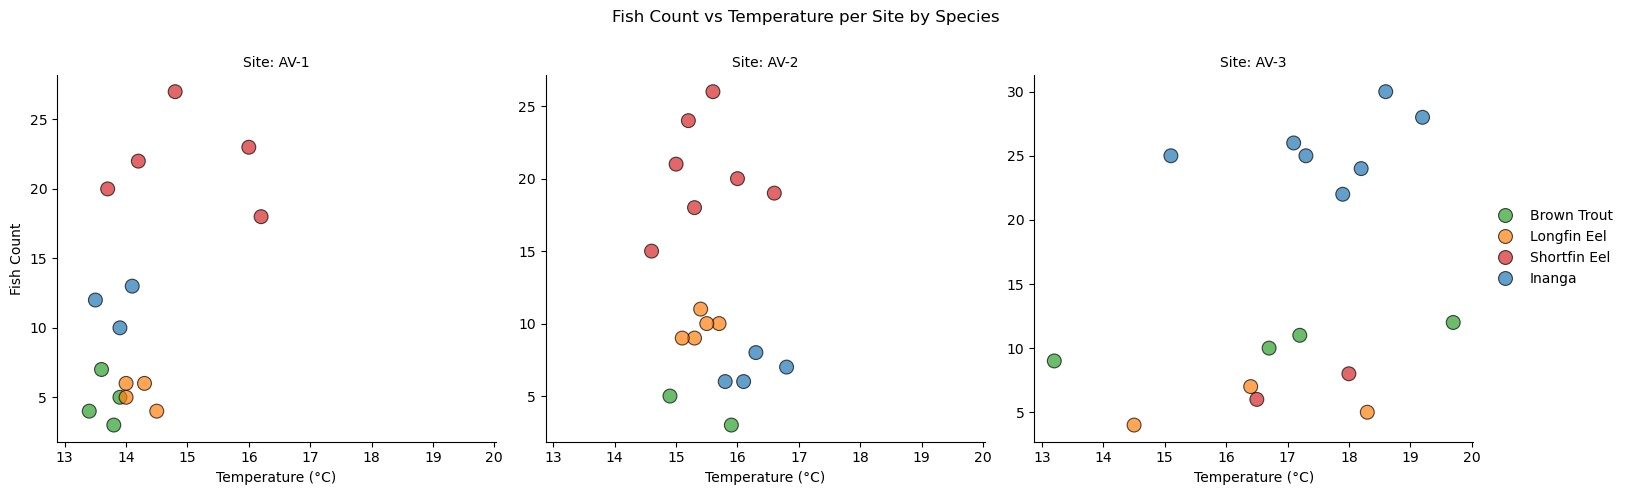

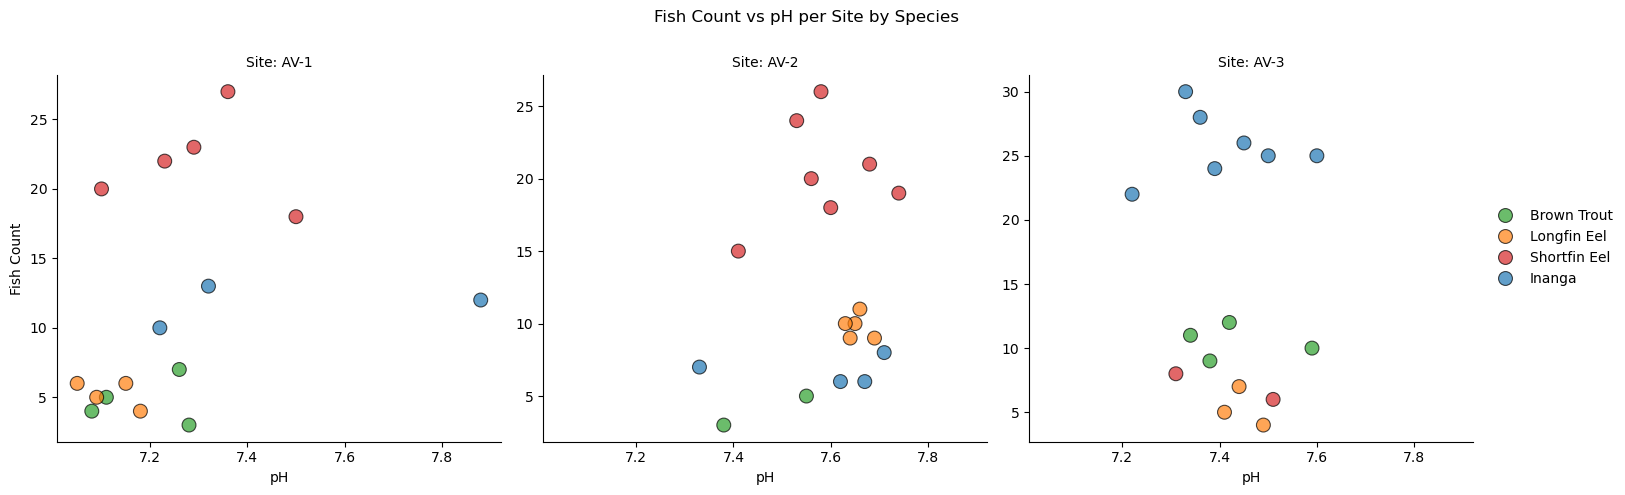

In [37]:
## Import libraries
#import pandas as pd
#import matplotlib.pyplot as plt
#import seaborn as sns
#
## Read the datasets
#water_quality = pd.read_csv('water_quality.csv', parse_dates=['Date'])
#fish_population = pd.read_csv('fish_population.csv', parse_dates=['Date'])
#
## Merge datasets on Site ID and Date
#data = pd.merge(water_quality, fish_population, on=['Site ID','Date'], how='inner')

# Scatter plot: Temperature vs Count per Site, colored by Species
g_temp = sns.FacetGrid(data, col='Site ID', height=5, sharey=False)
g_temp.map_dataframe(sns.scatterplot, x='Temperature (°C)', y='Count', hue='Species', s=100, alpha=0.7, edgecolor='black')
g_temp.add_legend()
g_temp.set_axis_labels('Temperature (°C)', 'Fish Count')
g_temp.set_titles('Site: {col_name}')
plt.subplots_adjust(top=0.85)
g_temp.fig.suptitle('Fish Count vs Temperature per Site by Species')
plt.show()

# Scatter plot: pH vs Count per Site, colored by Species
g_pH = sns.FacetGrid(data, col='Site ID', height=5, sharey=False)
g_pH.map_dataframe(sns.scatterplot, x='pH', y='Count', hue='Species', s=100, alpha=0.7, edgecolor='black')
g_pH.add_legend()
g_pH.set_axis_labels('pH', 'Fish Count')
g_pH.set_titles('Site: {col_name}')
plt.subplots_adjust(top=0.85)
g_pH.fig.suptitle('Fish Count vs pH per Site by Species')
plt.show()


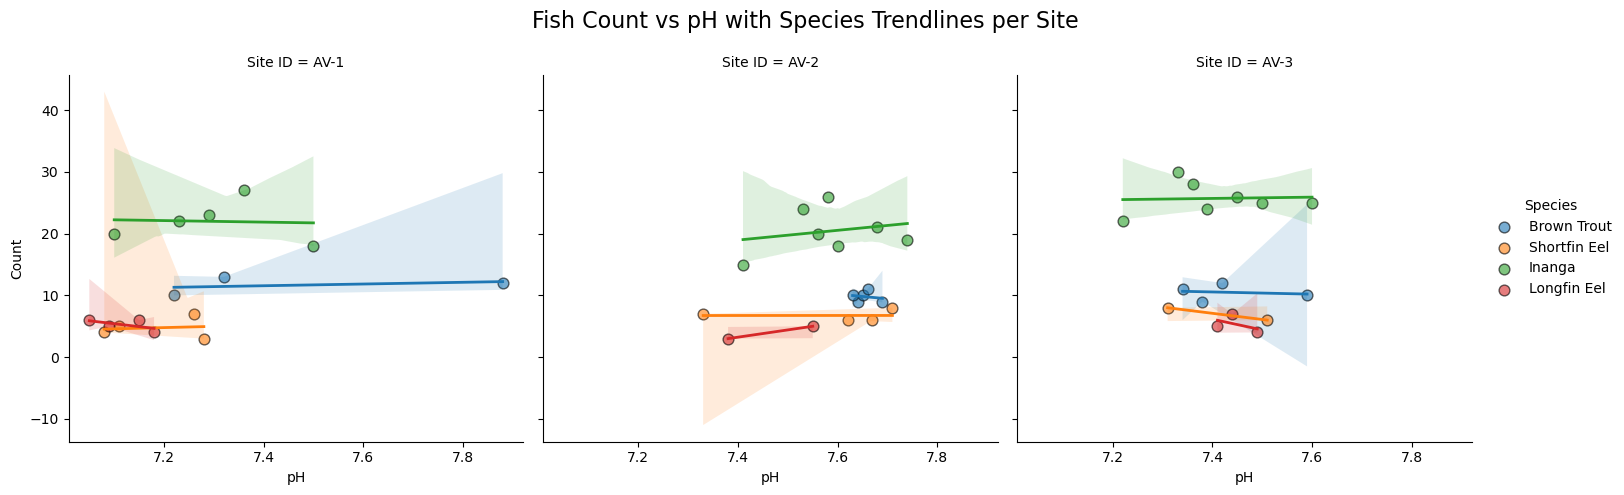

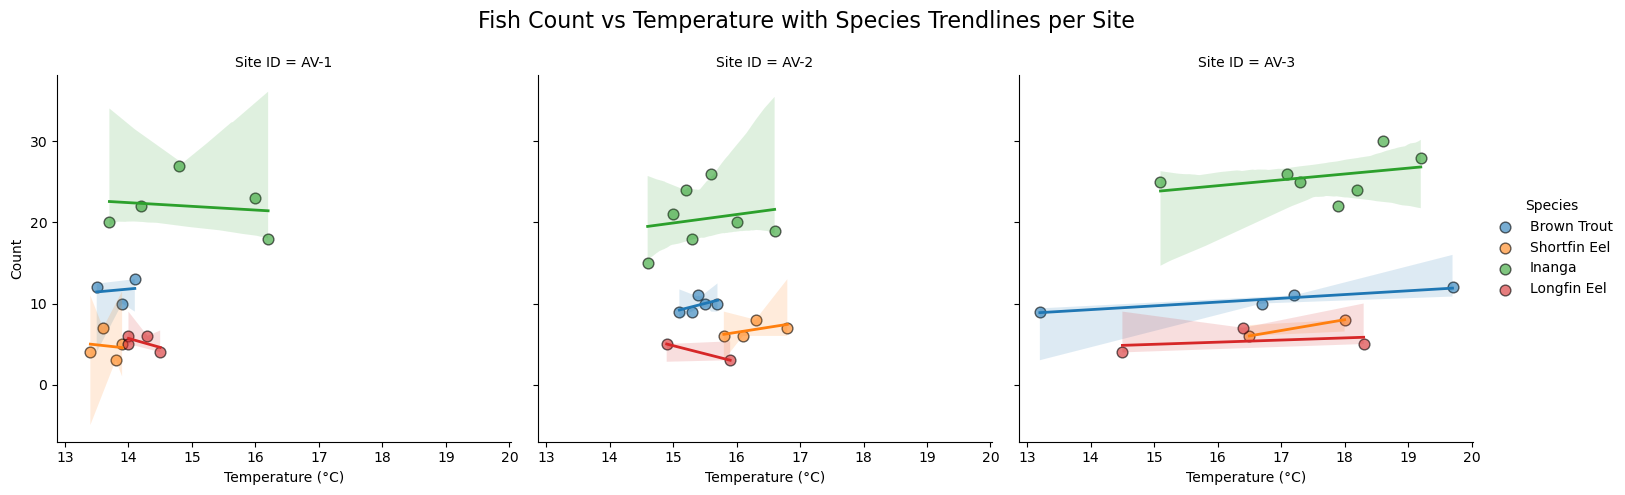

In [38]:
# Scatter plot with regression lines per species for pH vs Count, faceted by Site ID
sns.lmplot(
    data=data,
    x='pH',
    y='Count',
    hue='Species',
    col='Site ID',        # Create a separate plot for each site
    height=5,
    aspect=1.0,
    scatter_kws={'alpha':0.6, 'edgecolor':'black', 's':60},
    line_kws={'linewidth':2}
)

plt.subplots_adjust(top=0.85)  # Adjust to make space for the title
plt.suptitle('Fish Count vs pH with Species Trendlines per Site', fontsize=16)
plt.xlabel('pH')
plt.ylabel('Fish Count')

plt.show()


# Scatter plot with regression lines per species for Temperature vs Count, faceted by Site ID
sns.lmplot(
    data=data,
    x='Temperature (°C)',
    y='Count',
    hue='Species',
    col='Site ID',        # Create a separate plot for each site
    height=5,
    aspect=1.0,
    scatter_kws={'alpha':0.6, 'edgecolor':'black', 's':60},
    line_kws={'linewidth':2}
)

plt.subplots_adjust(top=0.85)  # Adjust to make space for the title
plt.suptitle('Fish Count vs Temperature with Species Trendlines per Site', fontsize=16)
plt.xlabel('Temperature (°C)')
plt.ylabel('Fish Count')

plt.show()


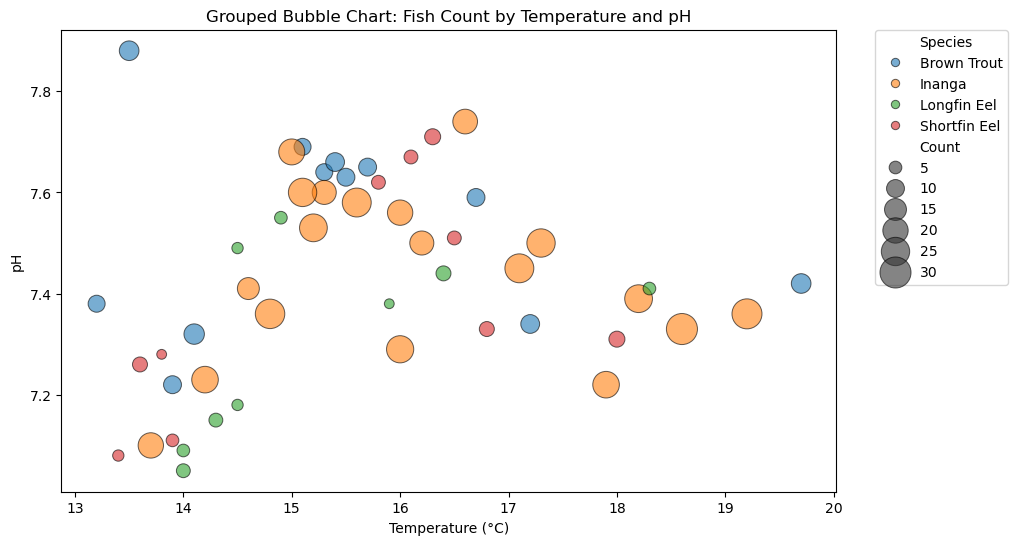

In [39]:
# Ensure data is sorted/grouped (optional)
data_sorted = data.sort_values(['Site ID', 'Species', 'Date'])

# Bubble chart: Temperature vs pH
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=data_sorted,
    x='Temperature (°C)',
    y='pH',
    hue='Species',               # Different colors per species
    size='Count',                # Bubble size represents fish count
    sizes=(50, 500),             # Adjust min/max bubble size
    alpha=0.6,
    edgecolor='black'
)

plt.title('Grouped Bubble Chart: Fish Count by Temperature and pH')
plt.xlabel('Temperature (°C)')
plt.ylabel('pH')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)  # Move legend outside

plt.show()


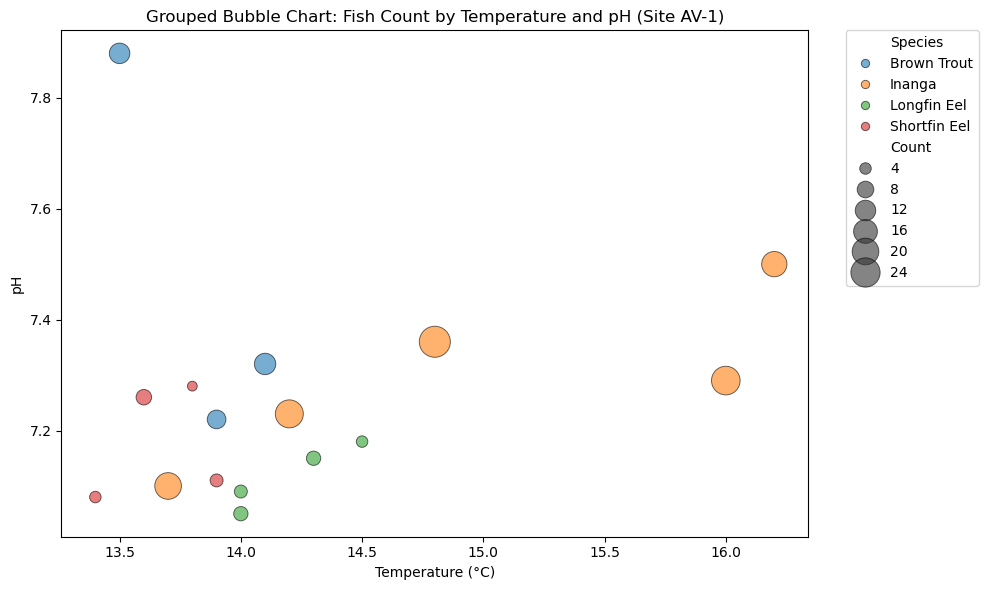

In [40]:
# Ensure data is sorted/grouped (optional)
data_sorted = data.sort_values(['Site ID', 'Species', 'Date'])

# Filter for Site ID AV-1
data_av1 = data_sorted[data_sorted['Site ID'] == 'AV-1']

# Bubble chart: Temperature vs pH for AV-1
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=data_av1,
    x='Temperature (°C)',
    y='pH',
    hue='Species',         # Different colors per species
    size='Count',          # Bubble size represents fish count
    sizes=(50, 500),       # Adjust min/max bubble size
    alpha=0.6,
    edgecolor='black'
)

plt.title('Grouped Bubble Chart: Fish Count by Temperature and pH (Site AV-1)')
plt.xlabel('Temperature (°C)')
plt.ylabel('pH')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()


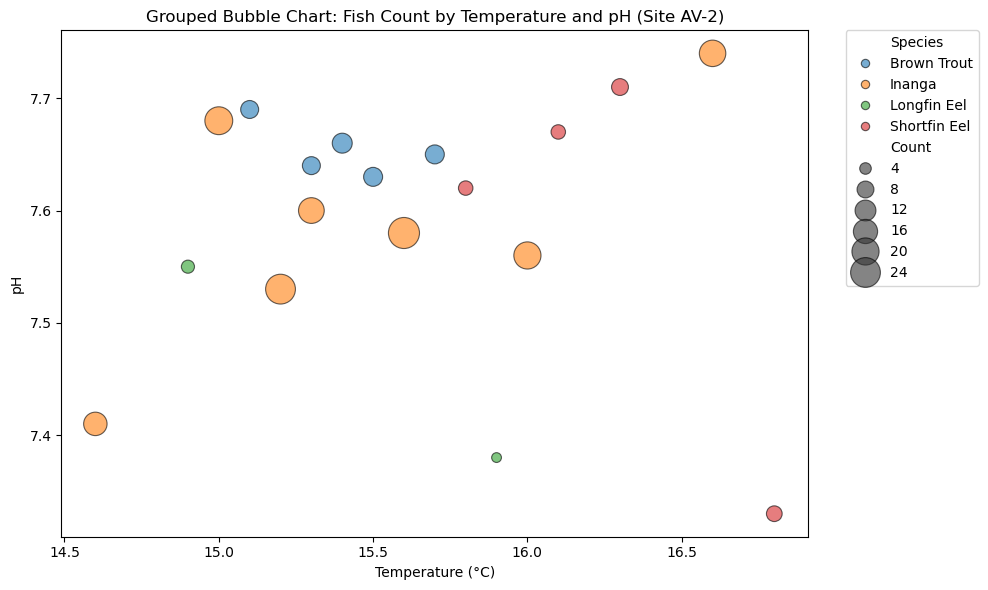

In [41]:
# Ensure data is sorted/grouped (optional)
data_sorted = data.sort_values(['Site ID', 'Species', 'Date'])

# Filter for Site ID AV-1
data_av1 = data_sorted[data_sorted['Site ID'] == 'AV-2']

# Bubble chart: Temperature vs pH for AV-1
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=data_av1,
    x='Temperature (°C)',
    y='pH',
    hue='Species',         # Different colors per species
    size='Count',          # Bubble size represents fish count
    sizes=(50, 500),       # Adjust min/max bubble size
    alpha=0.6,
    edgecolor='black'
)

plt.title('Grouped Bubble Chart: Fish Count by Temperature and pH (Site AV-2)')
plt.xlabel('Temperature (°C)')
plt.ylabel('pH')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()


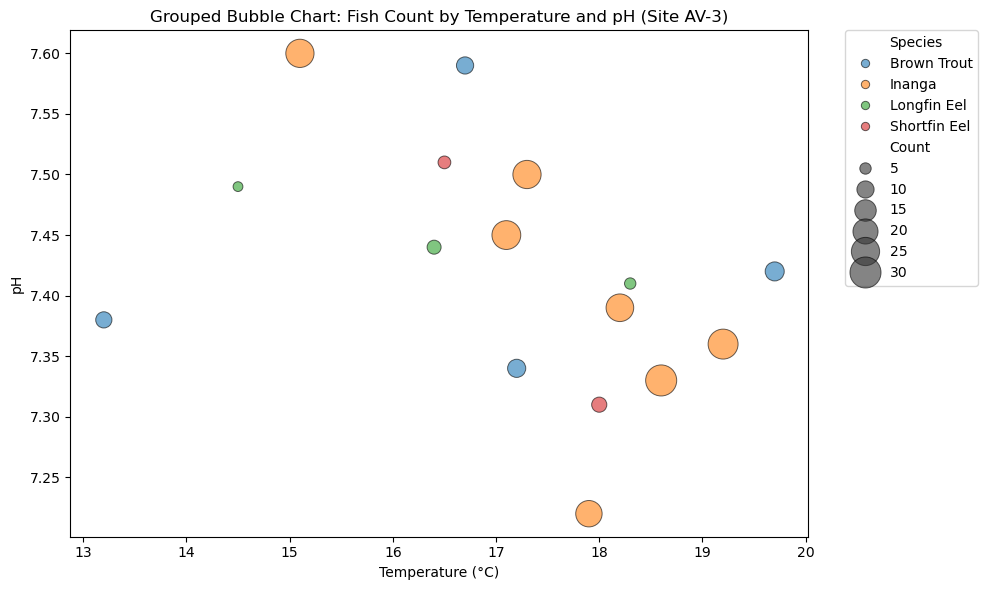

In [42]:
# Ensure data is sorted/grouped (optional)
data_sorted = data.sort_values(['Site ID', 'Species', 'Date'])

# Filter for Site ID AV-1
data_av1 = data_sorted[data_sorted['Site ID'] == 'AV-3']

# Bubble chart: Temperature vs pH for AV-1
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=data_av1,
    x='Temperature (°C)',
    y='pH',
    hue='Species',         # Different colors per species
    size='Count',          # Bubble size represents fish count
    sizes=(50, 500),       # Adjust min/max bubble size
    alpha=0.6,
    edgecolor='black'
)

plt.title('Grouped Bubble Chart: Fish Count by Temperature and pH (Site AV-3)')
plt.xlabel('Temperature (°C)')
plt.ylabel('pH')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()


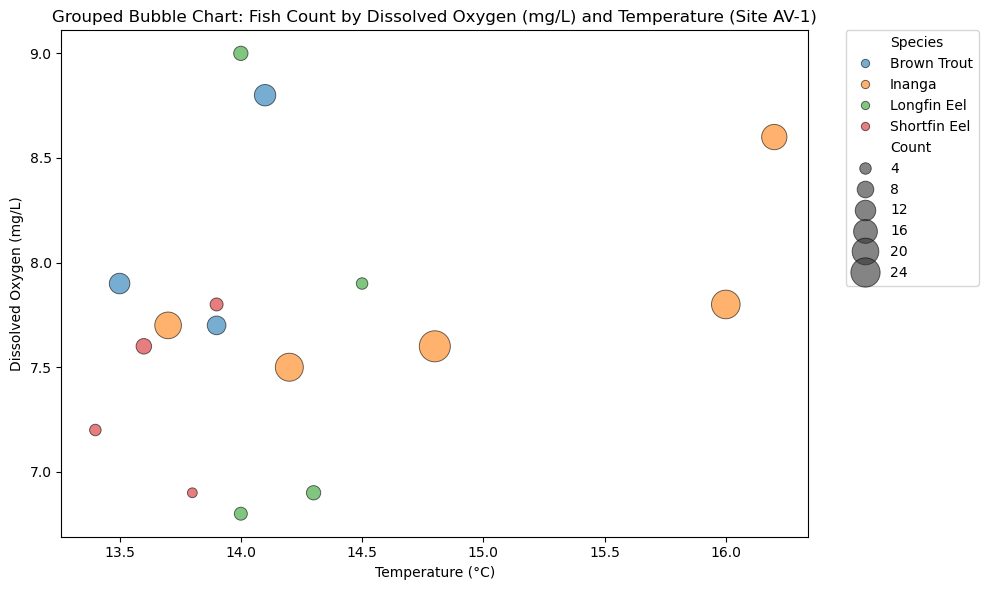

In [43]:
# Ensure data is sorted/grouped (optional)
data_sorted = data.sort_values(['Site ID', 'Species', 'Date'])

# Filter for Site ID AV-1
data_av1 = data_sorted[data_sorted['Site ID'] == 'AV-1']

# Bubble chart: Temperature vs pH for AV-1
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=data_av1,
    x='Temperature (°C)',
    y='Dissolved Oxygen (mg/L)',
    hue='Species',         # Different colors per species
    size='Count',          # Bubble size represents fish count
    sizes=(50, 500),       # Adjust min/max bubble size
    alpha=0.6,
    edgecolor='black'
)

plt.title('Grouped Bubble Chart: Fish Count by Dissolved Oxygen (mg/L) and Temperature (Site AV-1)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Dissolved Oxygen (mg/L)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()


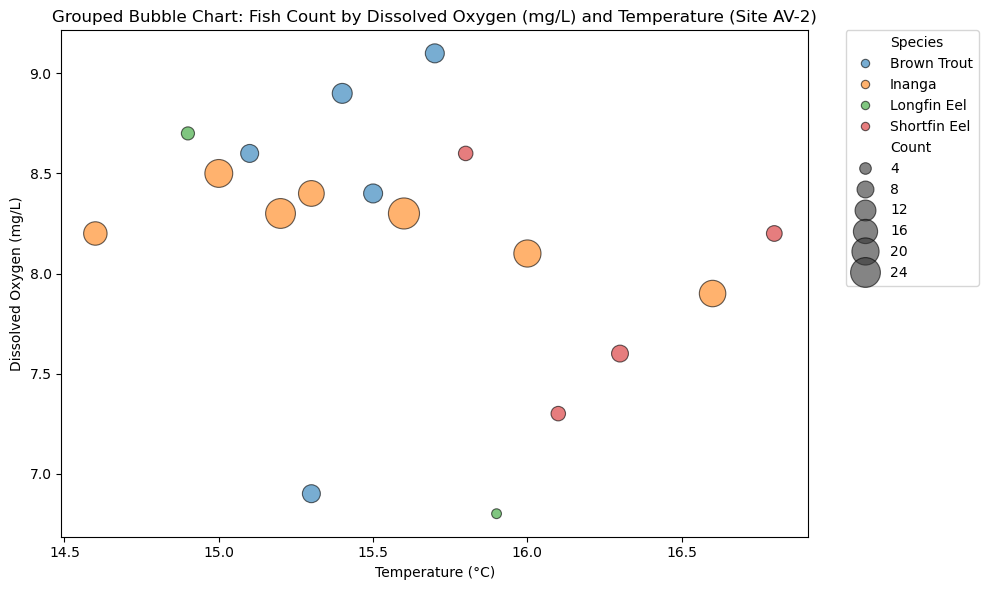

In [44]:
# Ensure data is sorted/grouped (optional)
data_sorted = data.sort_values(['Site ID', 'Species', 'Date'])

# Filter for Site ID AV-1
data_av1 = data_sorted[data_sorted['Site ID'] == 'AV-2']

# Bubble chart: Temperature vs pH for AV-1
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=data_av1,
    x='Temperature (°C)',
    y='Dissolved Oxygen (mg/L)',
    hue='Species',         # Different colors per species
    size='Count',          # Bubble size represents fish count
    sizes=(50, 500),       # Adjust min/max bubble size
    alpha=0.6,
    edgecolor='black'
)

plt.title('Grouped Bubble Chart: Fish Count by Dissolved Oxygen (mg/L) and Temperature (Site AV-2)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Dissolved Oxygen (mg/L)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()


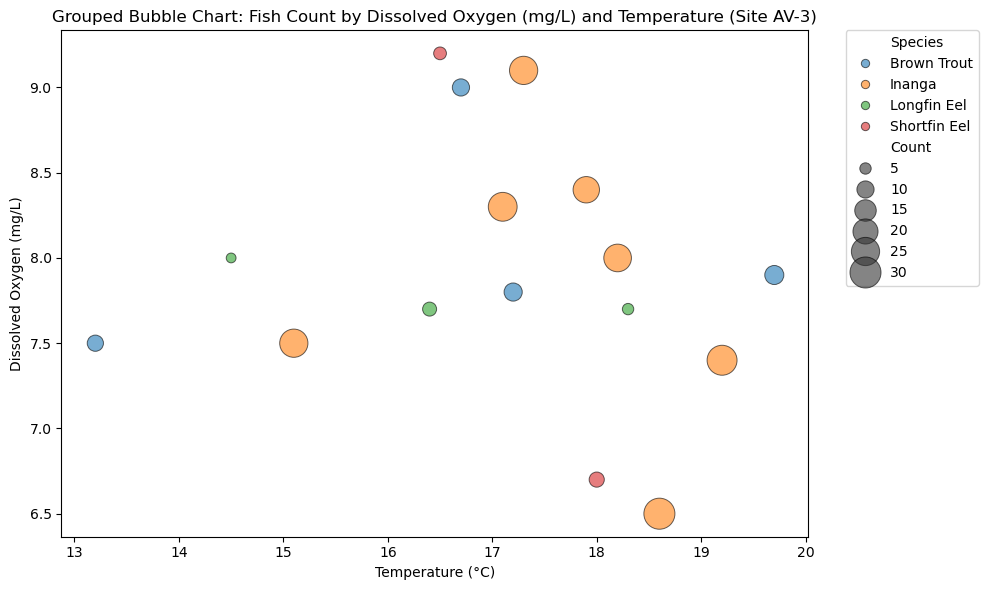

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure data is sorted/grouped (optional)
data_sorted = data.sort_values(['Site ID', 'Species', 'Date'])

# Filter for Site ID AV-1
data_av1 = data_sorted[data_sorted['Site ID'] == 'AV-3']

# Bubble chart: Temperature vs pH for AV-1
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=data_av1,
    x='Temperature (°C)',
    y='Dissolved Oxygen (mg/L)',
    hue='Species',         # Different colors per species
    size='Count',          # Bubble size represents fish count
    sizes=(50, 500),       # Adjust min/max bubble size
    alpha=0.6,
    edgecolor='black'
)

plt.title('Grouped Bubble Chart: Fish Count by Dissolved Oxygen (mg/L) and Temperature (Site AV-3)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Dissolved Oxygen (mg/L)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()


In [46]:
### Independent variables
X = data[['Temperature (°C)', 'pH', 'Dissolved Oxygen (mg/L)']]  # update column names as in your dataset
y = data['Count']

# Add constant for statsmodels
X_sm = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Count   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     2.198
Date:                Sun, 21 Sep 2025   Prob (F-statistic):              0.101
Time:                        19:32:47   Log-Likelihood:                -172.22
No. Observations:                  50   AIC:                             352.4
Df Residuals:                      46   BIC:                             360.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

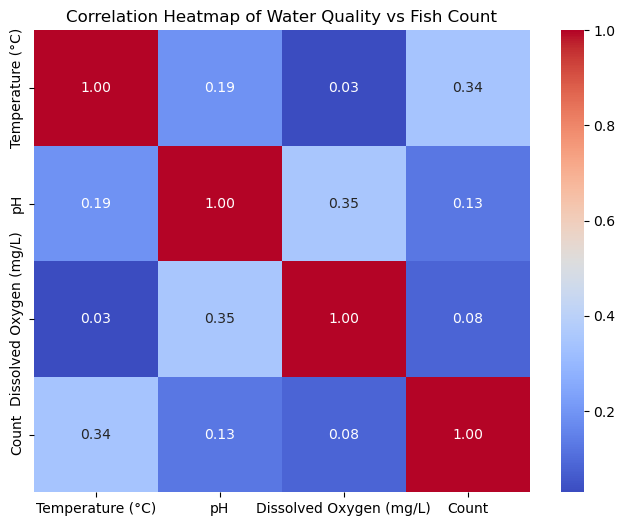

In [47]:
plt.figure(figsize=(8,6))
sns.heatmap(data[['Temperature (°C)', 'pH', 'Dissolved Oxygen (mg/L)', 'Count']].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Water Quality vs Fish Count")
plt.show()

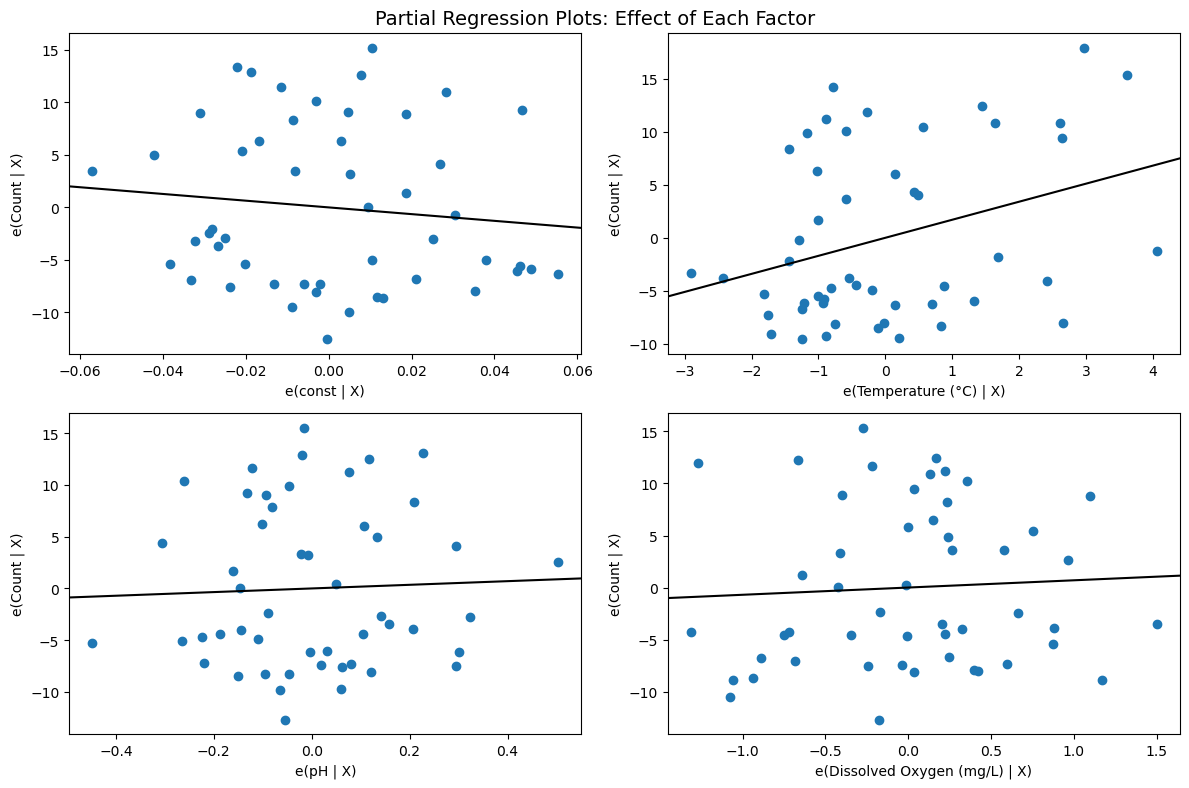

In [48]:
# Cell 6: Partial regression plots
fig = plt.figure(figsize=(12,8))
sm.graphics.plot_partregress_grid(model, fig=fig)
plt.suptitle("Partial Regression Plots: Effect of Each Factor", fontsize=14)
plt.show()


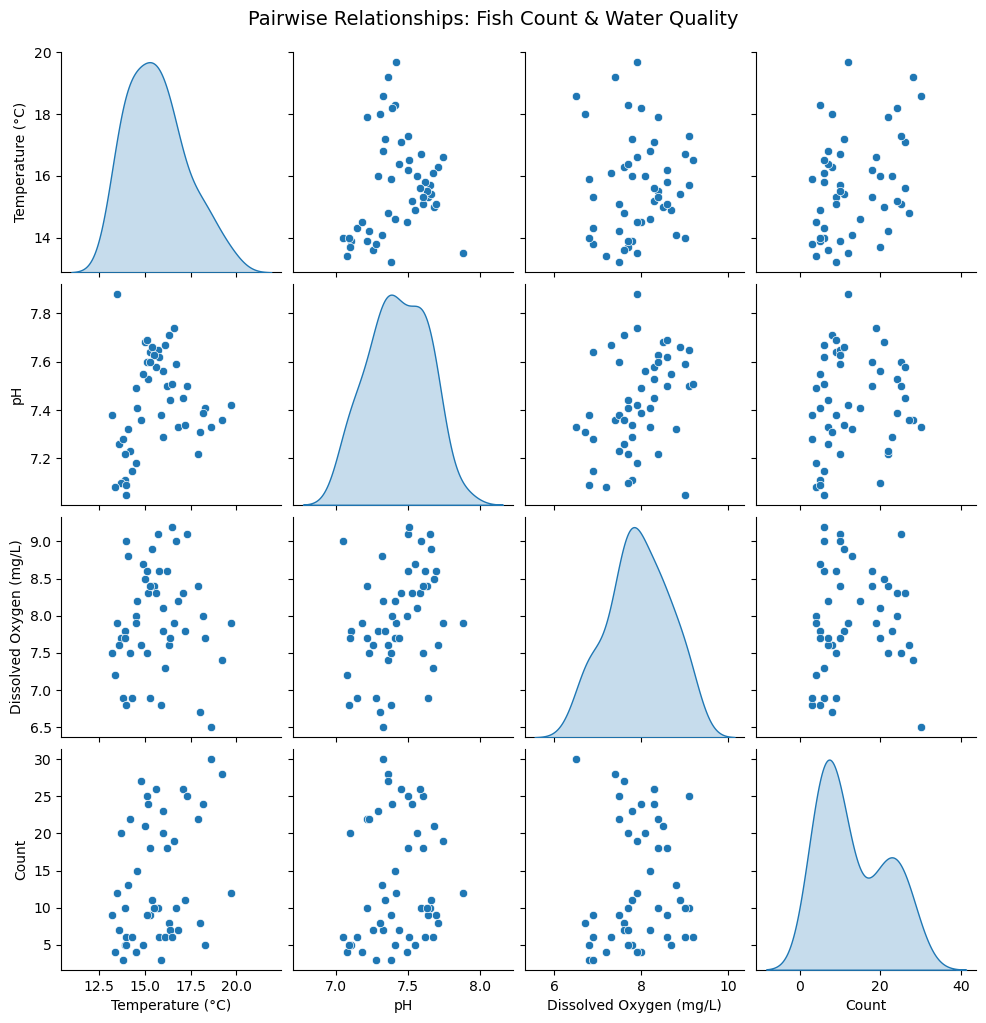

In [49]:
# Cell 7: Pairplot
sns.pairplot(data[['Temperature (°C)', 'pH', 'Dissolved Oxygen (mg/L)', 'Count']], diag_kind="kde")
plt.suptitle("Pairwise Relationships: Fish Count & Water Quality", y=1.02, fontsize=14)
plt.show()

C:\Users\desha\AppData\Local\Temp\ipykernel_51232\1466940578.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  z_surf = (model.params[0] +
C:\Users\desha\AppData\Local\Temp\ipykernel_51232\1466940578.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model.params[1]*x_surf +
C:\Users\desha\AppData\Local\Temp\ipykernel_51232\1466940578.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model.params[2]*y_surf +
C:\Users\desha\A

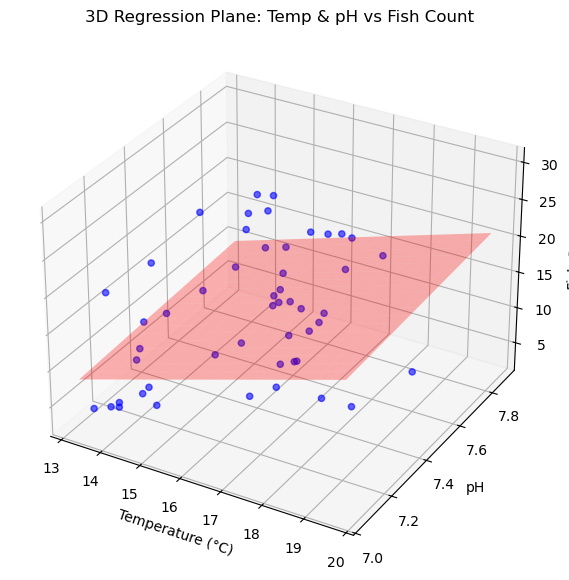

In [50]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(data['Temperature (°C)'], data['pH'], y, c='blue', alpha=0.6)

# Create grid for plane
x_surf, y_surf = np.meshgrid(np.linspace(data['Temperature (°C)'].min(), data['Temperature (°C)'].max(), 20),
                             np.linspace(data['pH'].min(), data['pH'].max(), 20))
z_surf = (model.params[0] +
          model.params[1]*x_surf +
          model.params[2]*y_surf +
          model.params[3]*data['Dissolved Oxygen (mg/L)'].mean())  # holding DO constant

ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.3, color='red')

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("pH")
ax.set_zlabel("Fish Count")
plt.title("3D Regression Plane: Temp & pH vs Fish Count")
plt.show()


In [51]:
# Cell 6: Site-wise regression models
site_results = {}

for site, subset in data.groupby('Site ID'):
    X_site = subset[['Temperature (°C)', 'pH', 'Dissolved Oxygen (mg/L)']]
    y_site = subset['Count']
    X_sm_site = sm.add_constant(X_site)

    model_site = sm.OLS(y_site, X_sm_site).fit()
    site_results[site] = model_site

    print(f"\n===== Site {site} =====")
    print(model_site.summary())



===== Site AV-1 =====
                            OLS Regression Results                            
Dep. Variable:                  Count   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.178
Method:                 Least Squares   F-statistic:                     2.084
Date:                Sun, 21 Sep 2025   Prob (F-statistic):              0.156
Time:                        19:32:53   Log-Likelihood:                -52.035
No. Observations:                  16   AIC:                             112.1
Df Residuals:                      12   BIC:                             115.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
con

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)


C:\Users\desha\AppData\Local\Temp\ipykernel_51232\2951399006.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  z_surf = (model_site.params[0] +
C:\Users\desha\AppData\Local\Temp\ipykernel_51232\2951399006.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_site.params[1]*x_surf +
C:\Users\desha\AppData\Local\Temp\ipykernel_51232\2951399006.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_site.params[2]*y_surf +
C

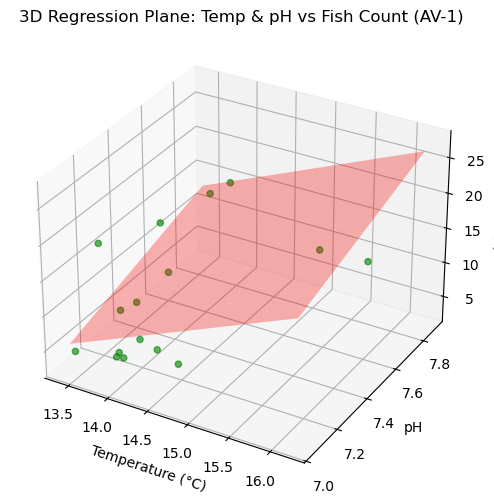

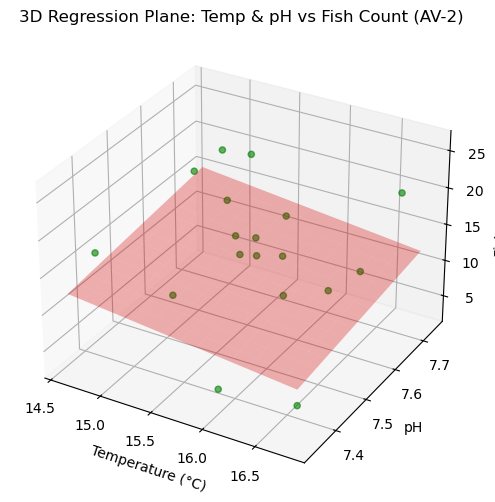

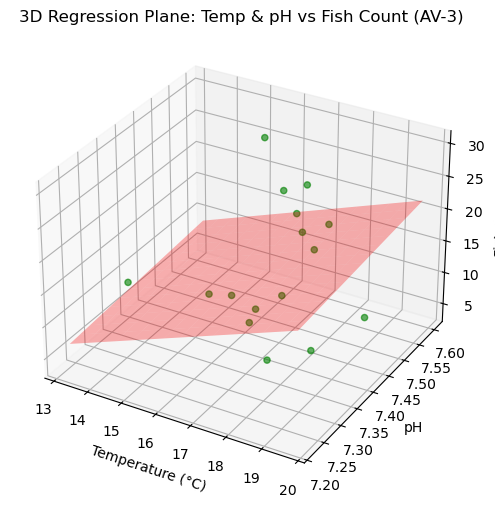

In [52]:
# Cell 7: Site-wise scatter plots with regression planes
for site, subset in data.groupby('Site ID'):
    y_site = subset['Count']
    model_site = site_results[site]

    fig = plt.figure(figsize=(9,6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(subset['Temperature (°C)'], subset['pH'], y_site, c='green', alpha=0.6)

    x_surf, y_surf = np.meshgrid(np.linspace(subset['Temperature (°C)'].min(), subset['Temperature (°C)'].max(), 15),
                                 np.linspace(subset['pH'].min(), subset['pH'].max(), 15))
    z_surf = (model_site.params[0] +
              model_site.params[1]*x_surf +
              model_site.params[2]*y_surf +
              model_site.params[3]*subset['Dissolved Oxygen (mg/L)'].mean())

    ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.3, color='red')

    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("pH")
    ax.set_zlabel("Fish Count")
    plt.title(f"3D Regression Plane: Temp & pH vs Fish Count ({site})")
    plt.show()


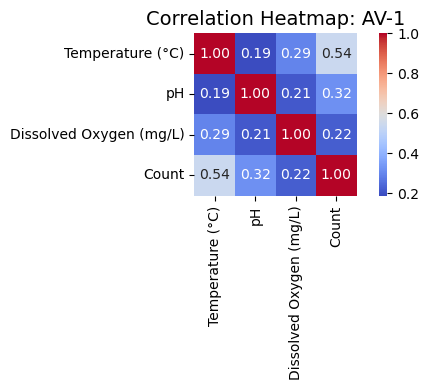

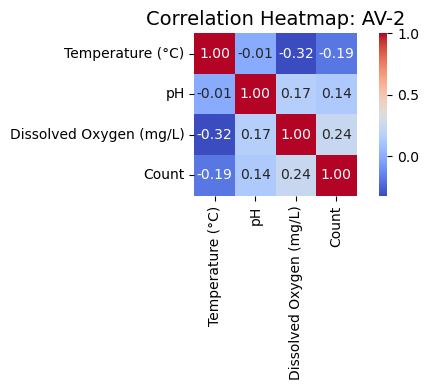

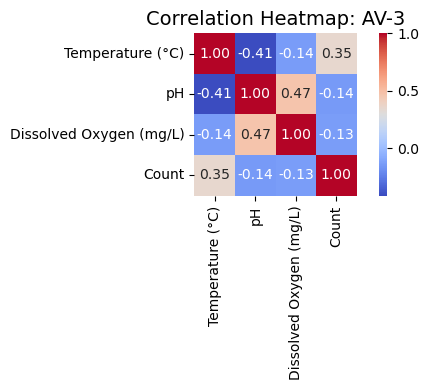

In [53]:
# Cell: Site-wise Correlation Heatmaps

sites = data['Site ID'].unique()

for site in sites:
    site_data = data[data['Site ID'] == site]

    # Compute correlation
    corr = site_data[['Temperature (°C)', 'pH', 'Dissolved Oxygen (mg/L)', 'Count']].corr()

    # Plot heatmap
    plt.figure(figsize=(6,4))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True, square=True)
    plt.title(f"Correlation Heatmap: {site}", fontsize=14)
    plt.tight_layout()
    plt.show()


In [54]:
# import libraries
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

In [55]:
# Cell 2: Define X (independent) and y (dependent)
X = data[['Temperature (°C)', 'pH', 'Dissolved Oxygen (mg/L)']]
y = data['Count']

# Add constant for intercept
X = sm.add_constant(X)

In [56]:
# Cell 3: Fit model
model = sm.OLS(y, X).fit()

# Model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Count   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     2.198
Date:                Sun, 21 Sep 2025   Prob (F-statistic):              0.101
Time:                        19:32:55   Log-Likelihood:                -172.22
No. Observations:                  50   AIC:                             352.4
Df Residuals:                      46   BIC:                             360.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [57]:
# Cell 4: Variance Inflation Factor (VIF)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

                   feature          VIF
0                    const  1419.679670
1         Temperature (°C)     1.039122
2                       pH     1.184713
3  Dissolved Oxygen (mg/L)     1.142986


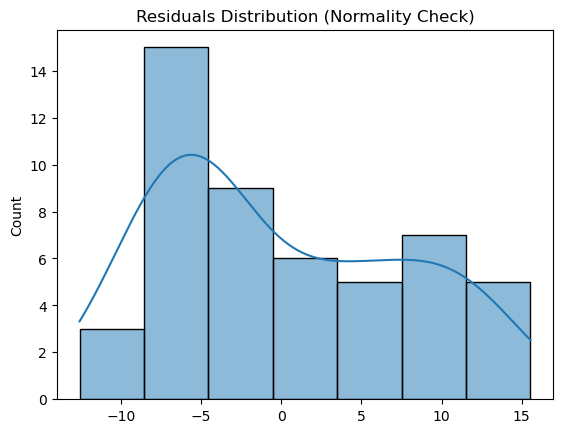

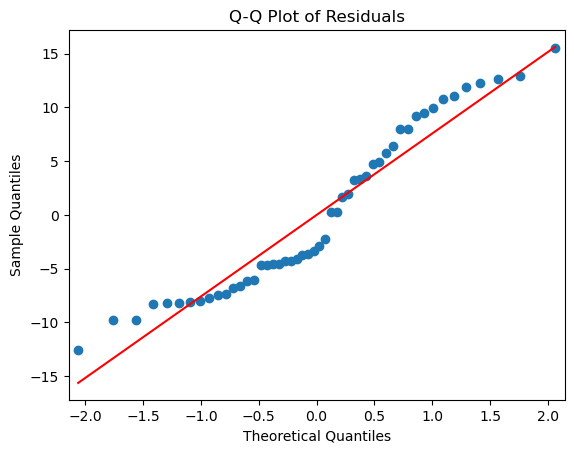

In [58]:
# Cell 5: Residual normality
residuals = model.resid

# Histogram + KDE
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution (Normality Check)")
plt.show()

# Q-Q plot
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

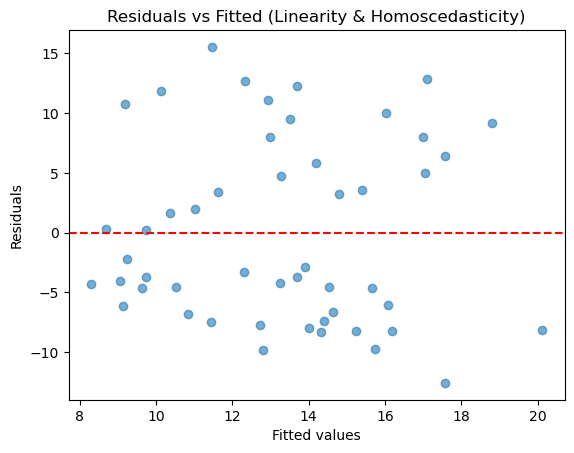

In [59]:
# Cell 6: Residuals vs Fitted
fitted = model.fittedvalues
plt.scatter(fitted, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Linearity & Homoscedasticity)")
plt.show()

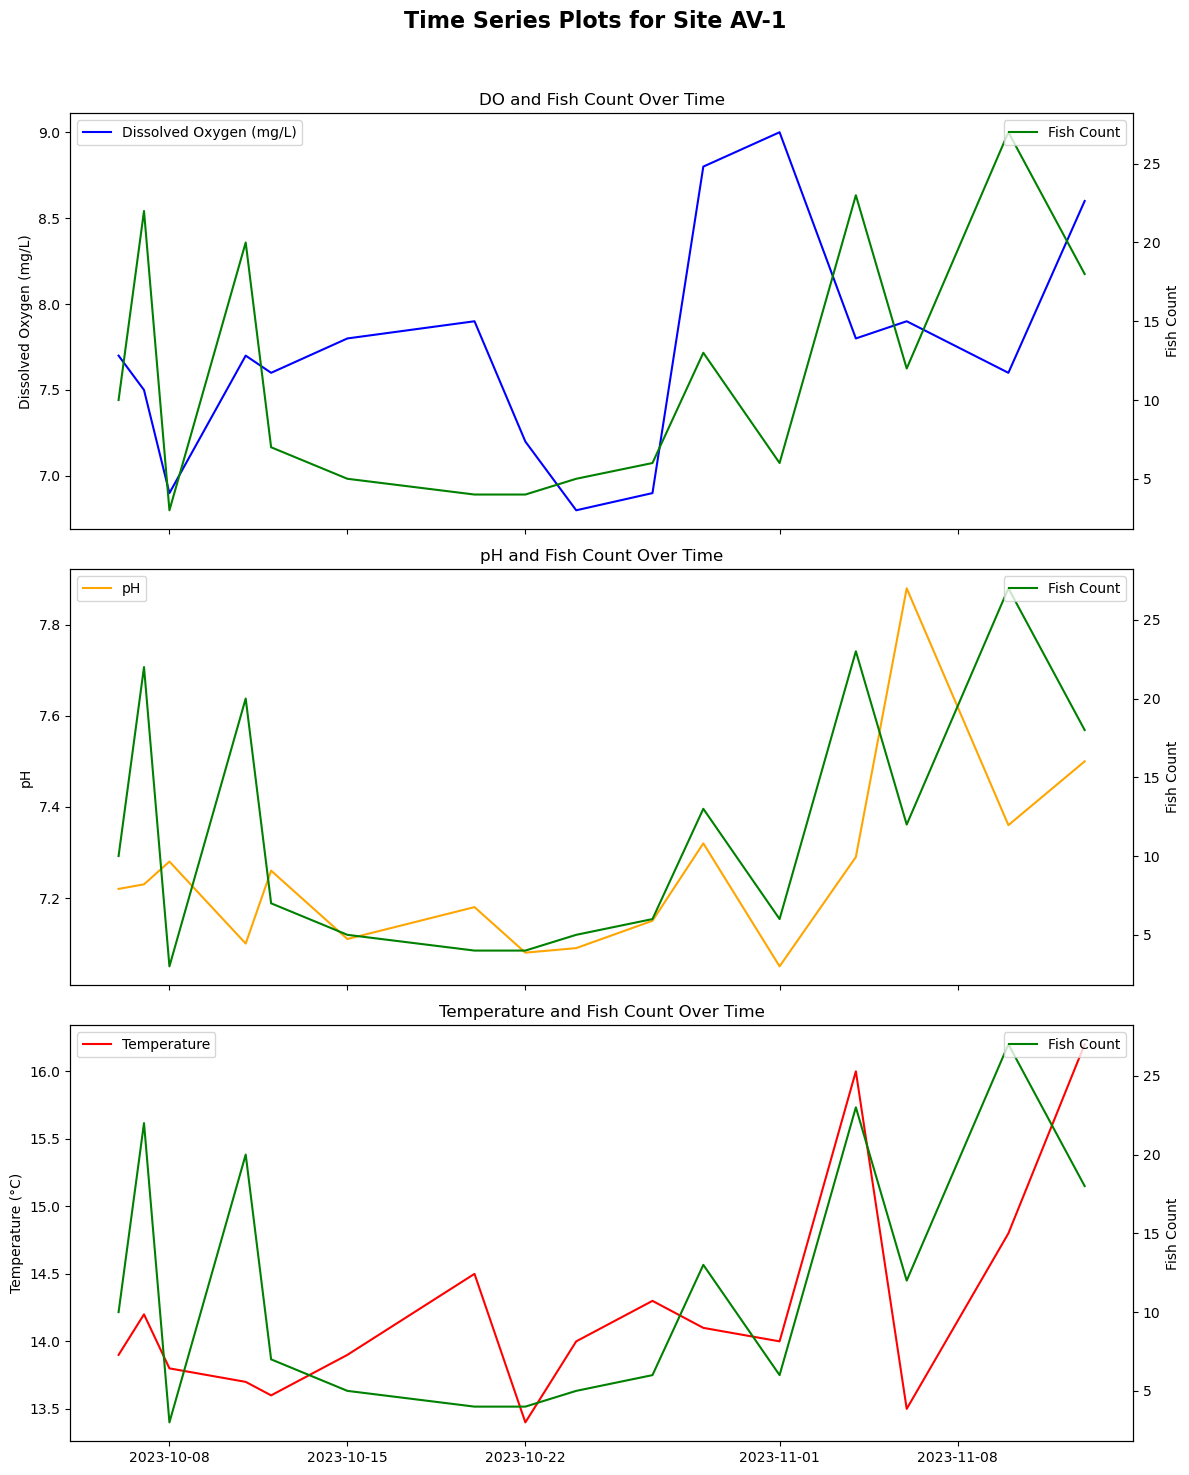

In [60]:
# Ensure Date is datetime
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True, errors='coerce')

site = "AV-1"
# Loop through sites
#for site in data['Site ID'].unique():
site_data = data[data['Site ID'] == site].sort_values('Date')

fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
fig.suptitle(f"Time Series Plots for Site {site}", fontsize=16, fontweight="bold")

# DO vs Fish Count
ax1 = axes[0]
ax1.plot(site_data['Date'], site_data['Dissolved Oxygen (mg/L)'], color='blue', label='DO')
ax2 = ax1.twinx()
ax2.plot(site_data['Date'], site_data['Count'], color='green', label='Fish Count')
ax1.set_ylabel("Dissolved Oxygen (mg/L)")
ax2.set_ylabel("Fish Count")
ax1.set_title("DO and Fish Count Over Time")
ax1.legend(["Dissolved Oxygen (mg/L)"], loc="upper left")
ax2.legend(["Fish Count"], loc="upper right")

# pH vs Fish Count
ax1 = axes[1]
ax1.plot(site_data['Date'], site_data['pH'], color='orange', label='pH')
ax2 = ax1.twinx()
ax2.plot(site_data['Date'], site_data['Count'], color='green', label='Fish Count')
ax1.set_ylabel("pH")
ax2.set_ylabel("Fish Count")
ax1.set_title("pH and Fish Count Over Time")
ax1.legend(["pH"], loc="upper left")
ax2.legend(["Fish Count"], loc="upper right")

# Temperature vs Fish Count
ax1 = axes[2]
ax1.plot(site_data['Date'], site_data['Temperature (°C)'], color='red', label='Temperature')
ax2 = ax1.twinx()
ax2.plot(site_data['Date'], site_data['Count'], color='green', label='Fish Count')
ax1.set_ylabel("Temperature (°C)")
ax2.set_ylabel("Fish Count")
ax1.set_title("Temperature and Fish Count Over Time")
ax1.legend(["Temperature"], loc="upper left")
ax2.legend(["Fish Count"], loc="upper right")

plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

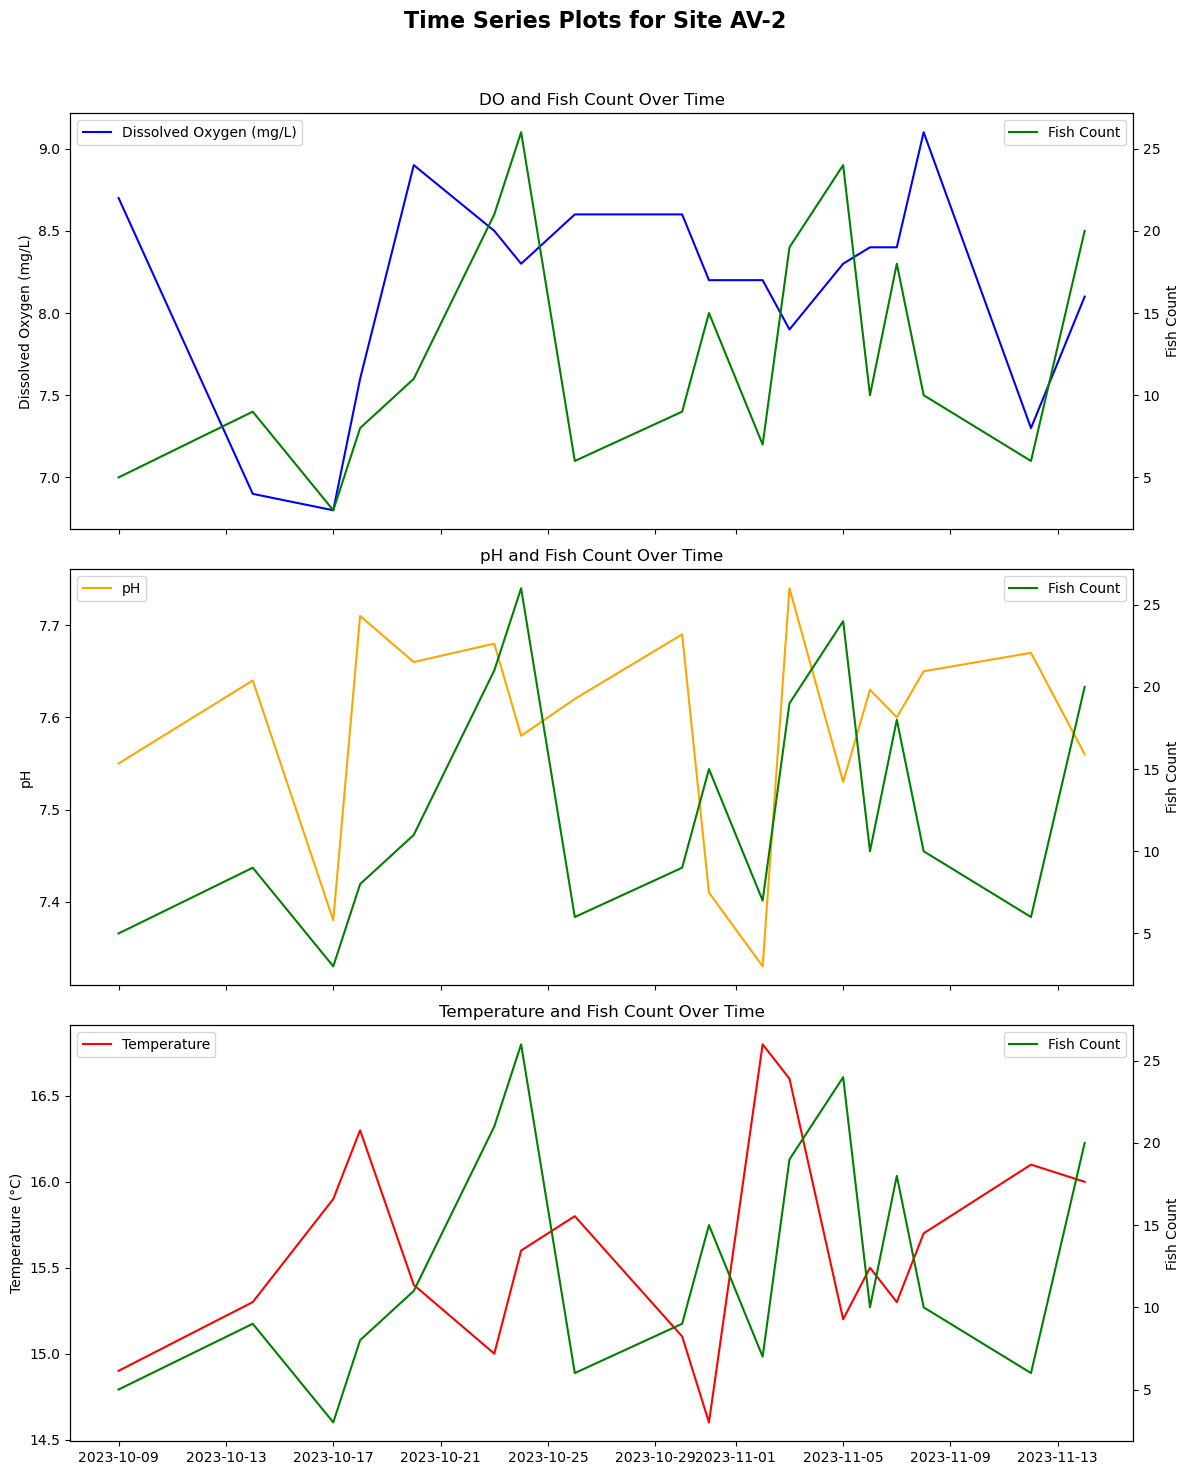

In [61]:
# Ensure Date is datetime
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True, errors='coerce')

site = "AV-2"
# Loop through sites
#for site in data['Site ID'].unique():
site_data = data[data['Site ID'] == site].sort_values('Date')

fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
fig.suptitle(f"Time Series Plots for Site {site}", fontsize=16, fontweight="bold")

# DO vs Fish Count
ax1 = axes[0]
ax1.plot(site_data['Date'], site_data['Dissolved Oxygen (mg/L)'], color='blue', label='DO')
ax2 = ax1.twinx()
ax2.plot(site_data['Date'], site_data['Count'], color='green', label='Fish Count')
ax1.set_ylabel("Dissolved Oxygen (mg/L)")
ax2.set_ylabel("Fish Count")
ax1.set_title("DO and Fish Count Over Time")
ax1.legend(["Dissolved Oxygen (mg/L)"], loc="upper left")
ax2.legend(["Fish Count"], loc="upper right")

# pH vs Fish Count
ax1 = axes[1]
ax1.plot(site_data['Date'], site_data['pH'], color='orange', label='pH')
ax2 = ax1.twinx()
ax2.plot(site_data['Date'], site_data['Count'], color='green', label='Fish Count')
ax1.set_ylabel("pH")
ax2.set_ylabel("Fish Count")
ax1.set_title("pH and Fish Count Over Time")
ax1.legend(["pH"], loc="upper left")
ax2.legend(["Fish Count"], loc="upper right")

# Temperature vs Fish Count
ax1 = axes[2]
ax1.plot(site_data['Date'], site_data['Temperature (°C)'], color='red', label='Temperature')
ax2 = ax1.twinx()
ax2.plot(site_data['Date'], site_data['Count'], color='green', label='Fish Count')
ax1.set_ylabel("Temperature (°C)")
ax2.set_ylabel("Fish Count")
ax1.set_title("Temperature and Fish Count Over Time")
ax1.legend(["Temperature"], loc="upper left")
ax2.legend(["Fish Count"], loc="upper right")

plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

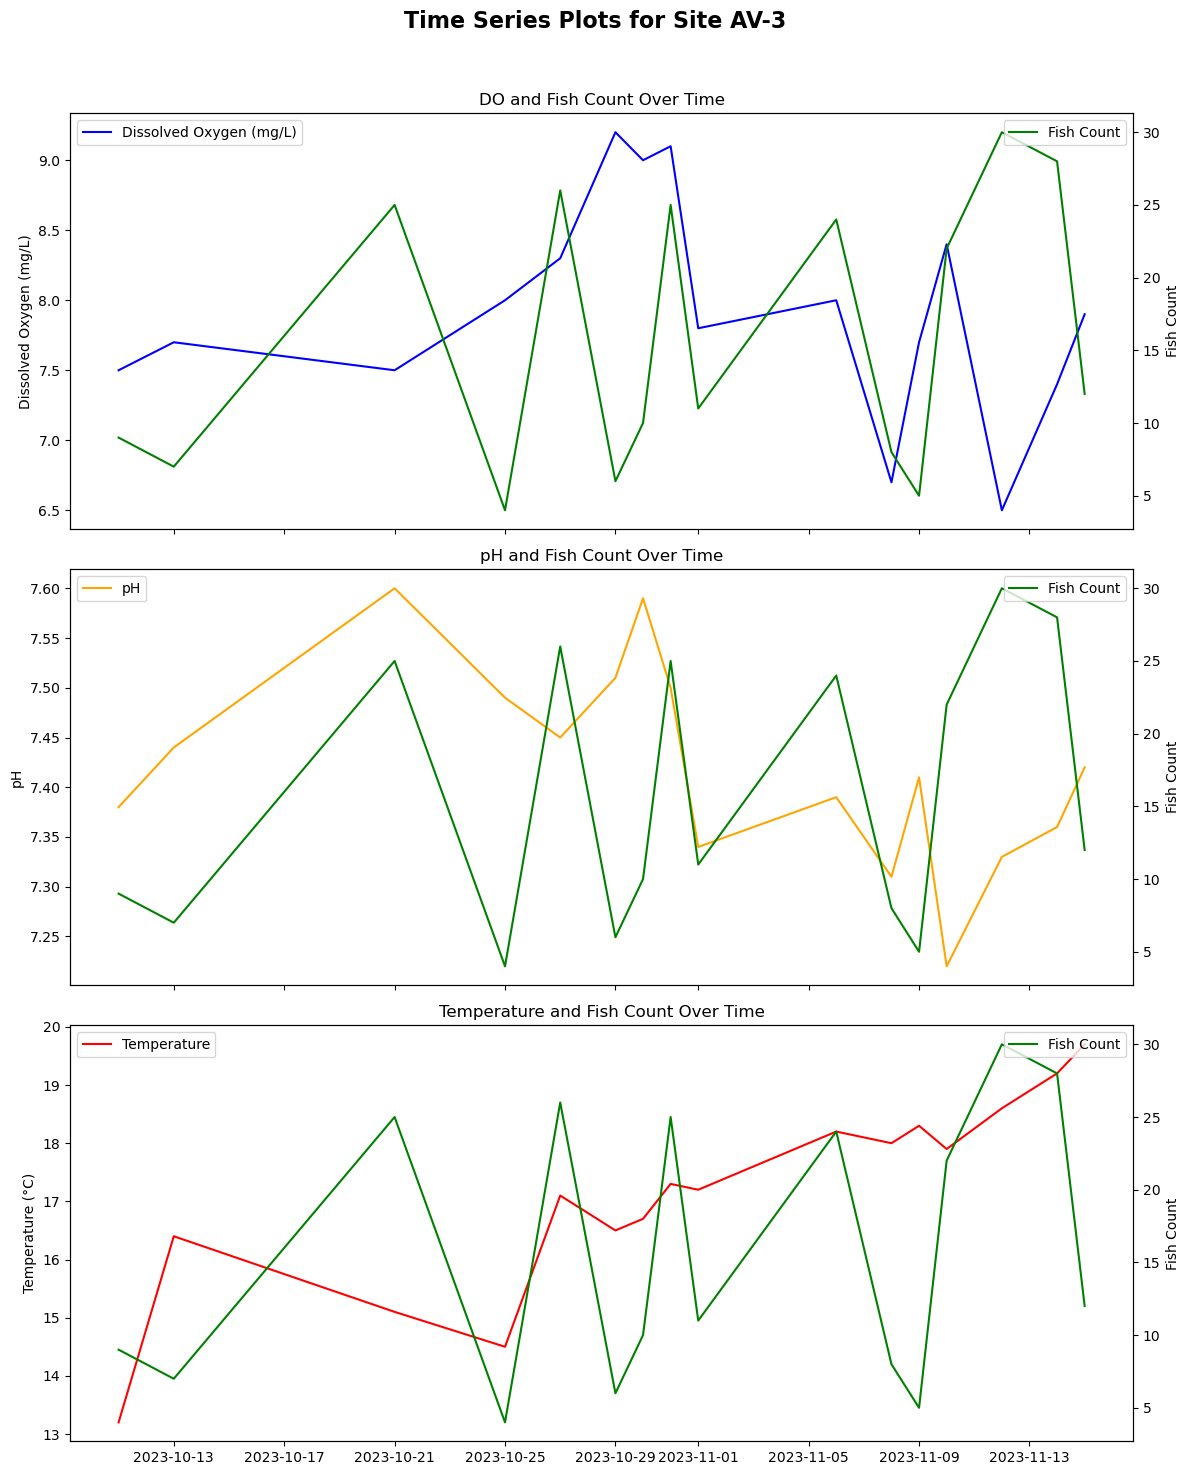

In [62]:
# Ensure Date is datetime
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True, errors='coerce')

site = "AV-3"
# Loop through sites
#for site in data['Site ID'].unique():
site_data = data[data['Site ID'] == site].sort_values('Date')

fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
fig.suptitle(f"Time Series Plots for Site {site}", fontsize=16, fontweight="bold")

# DO vs Fish Count
ax1 = axes[0]
ax1.plot(site_data['Date'], site_data['Dissolved Oxygen (mg/L)'], color='blue', label='DO')
ax2 = ax1.twinx()
ax2.plot(site_data['Date'], site_data['Count'], color='green', label='Fish Count')
ax1.set_ylabel("Dissolved Oxygen (mg/L)")
ax2.set_ylabel("Fish Count")
ax1.set_title("DO and Fish Count Over Time")
ax1.legend(["Dissolved Oxygen (mg/L)"], loc="upper left")
ax2.legend(["Fish Count"], loc="upper right")

# pH vs Fish Count
ax1 = axes[1]
ax1.plot(site_data['Date'], site_data['pH'], color='orange', label='pH')
ax2 = ax1.twinx()
ax2.plot(site_data['Date'], site_data['Count'], color='green', label='Fish Count')
ax1.set_ylabel("pH")
ax2.set_ylabel("Fish Count")
ax1.set_title("pH and Fish Count Over Time")
ax1.legend(["pH"], loc="upper left")
ax2.legend(["Fish Count"], loc="upper right")

# Temperature vs Fish Count
ax1 = axes[2]
ax1.plot(site_data['Date'], site_data['Temperature (°C)'], color='red', label='Temperature')
ax2 = ax1.twinx()
ax2.plot(site_data['Date'], site_data['Count'], color='green', label='Fish Count')
ax1.set_ylabel("Temperature (°C)")
ax2.set_ylabel("Fish Count")
ax1.set_title("Temperature and Fish Count Over Time")
ax1.legend(["Temperature"], loc="upper left")
ax2.legend(["Fish Count"], loc="upper right")

plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()